In [2]:
import my_data_manager as mdm
import pandas as pd
import cluster_utils as cu

cat = mdm.load_cat("Data/galaxies_subhalos_zphot.cat")
halos = mdm.separate_halos(cat)
clusters, groups = mdm.separate_clusters(halos)
clusters = clusters[:678]

#clean_clusters = [df[df.groupby("haloId")["haloId"].transform("count") > 3].reset_index(drop=True) for df in clusters]

#N = 21

#splus_clusters = [df[pd.to_numeric(df['mag_r'], errors = 'coerce') >= N].copy() for df in clusters]

#clusters = cu.retag_noise(clusters)
#splus_clusters = cu.retag_noise(splus_clusters)

#cluster_samples = {
#    "Raw": clusters,
#    "Clean": clean_clusters,
#    "SPLUS": splus_clusters
#}

/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(cat, delim_whitespace=True, header=None)
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:56: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cat, delim_whitespace=True, header=None)


In [3]:
import astro_utils as au
from astropy.stats import biweight_location, biweight_scale

clusters_mpc = []

for cluster in clusters:
    cluster = cluster.copy()

    cluster["RA"] = pd.to_numeric(cluster["RA"], errors="coerce")
    cluster["DEC"] = pd.to_numeric(cluster["DEC"], errors="coerce")
    cluster["z_app"] = pd.to_numeric(cluster["z_app"], errors="coerce")

    ra_center = biweight_location(cluster["RA"].values.astype(float))
    dec_center = biweight_location(cluster["DEC"].values.astype(float))
    z_center = biweight_location(cluster["z_app"].values.astype(float))

    x, y, z = au.gal_3D_Mpc_coords(
        ra=cluster["RA"].values,
        dec=cluster["DEC"].values,
        redshift_gal=cluster["z_app"].values,
        x_center=ra_center,
        y_center=dec_center,
        z_center=z_center
    )

    cluster["X_Mpc"] = x
    cluster["Y_Mpc"] = y
    cluster["Z_Mpc"] = z

    clusters_mpc.append(cluster)

In [ ]:
import cluster_utils as cu

clean_mpc_clusters = [df[df.groupby("haloId")["haloId"].transform("count") > 3].reset_index(drop=True) for df in clusters_mpc]

N = 21

splus_mpc_clusters = [df[pd.to_numeric(df['mag_r'], errors = 'coerce') >= N].copy() for df in clusters_mpc]

clusters_mpc = cu.retag_noise(clusters_mpc)
splus_mpc_clusters = cu.retag_noise(splus_mpc_clusters)

cluster_mpc_samples = {
    "Raw": clusters_mpc,
    "Clean": clean_mpc_clusters,
    "SPLUS": splus_mpc_clusters
}

In [4]:
import my_data_manager as mdm
import clustering_metrics as metrics
import pandas as pd

all_rows = []

for key in ["Raw", "Clean", "SPLUS"]:
    reported_results = mdm.load_results(f"Results/{key}_samples")
    df_times = metrics.compute_times(reported_results)

    for _, row in df_times.iterrows():
        all_rows.append({
            "Sample": key,
            "Method": row["Method"],

            # Full run over all clusters
            "Run_Mean": row["Run_Mean"],
            "Run_Std": row["Run_Std"],
            "Run_Summary": row["Run_Summary"],

            # Single algorithm execution on one cluster
            "Execution_Mean": row["Execution_Mean"],
            "Execution_Std": row["Execution_Std"],
            "Execution_Summary": row["Execution_Summary"],

            # Total accumulated runtime
            "Total_Time": row["Total_Time"],
        })

df_all_times = pd.DataFrame(all_rows)

# -------------------------
# PRINT
# -------------------------
display_cols = [
    "Sample",
    "Method",
    "Run_Summary",
    "Execution_Summary",
    "Total_Time"
]

print(df_all_times[display_cols].to_string(index=False))

# -------------------------
# SAVE XLSX
# -------------------------
xlsx_path = "Metrics/timing_summary.xlsx"
df_all_times.to_excel(xlsx_path, index=False)


Sample           Method              Run_Summary   Execution_Summary   Total_Time
   Raw          ML_BGMM      666.3552 ± 127.9013     0.9828 ± 2.7737 6.663552e+03
   Raw      ML_Affinity       243.5033 ± 72.8900     0.3591 ± 2.1665 2.435033e+03
   Raw         CALSAGOS    15511.7414 ± 221.3942  22.8787 ± 107.9192 1.551174e+05
   Raw ML_Agglomerative       205.7360 ± 48.6825     0.3034 ± 2.4731 2.057360e+03
   Raw        ML_DBSCAN          5.5730 ± 1.2558     0.0082 ± 0.0047 5.573042e+01
   Raw              DSP 107835.9819 ± 25784.6553 159.0501 ± 387.0825 1.078360e+06
   Raw        ML_Optics      258.9073 ± 100.4781     0.3819 ± 0.3289 2.589073e+03
   Raw       ML_HDBSCAN          8.1621 ± 3.0283     0.0120 ± 0.0101 8.162068e+01
   Raw        ML_Kmeans       173.8753 ± 28.0059     0.2565 ± 0.8809 1.738753e+03
 Clean          ML_BGMM         80.7058 ± 2.9546     0.1190 ± 0.2019 8.070581e+02
 Clean      ML_Affinity         26.4598 ± 1.4086     0.0390 ± 0.3941 2.645977e+02
 Clean         C

In [ ]:
import gc
from sklearn.metrics import v_measure_score, normalized_mutual_info_score, adjusted_rand_score
import my_data_manager as mdm
import clustering_metrics as metrics

performance_metrics = {
    "Vmeasure": v_measure_score,
    "NMI": normalized_mutual_info_score,
    "ARI": adjusted_rand_score
}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in performance_metrics.items():
    for key in keys:

        reuslts_dict = metrics.compute_performance_metric(mdm.load_results(f"Results/{key}_samples"), cluster_samples[key], metric_func)

        mdm.save_dict_to_excel(reuslts_dict, filename=f"Metrics/{metric_name}/{key}/results.xlsx")
        
        del reuslts_dict
        gc.collect()
    gc.collect()


In [ ]:
import gc
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import my_data_manager as mdm
import clustering_metrics as metrics

clustering_metrics = {
    "Silhouette": silhouette_score,
    "Calinski-Harabasz": calinski_harabasz_score,
    "Davies-Bouldin": davies_bouldin_score
}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in clustering_metrics.items():
    for key in keys:

        reuslts_dict = metrics.compute_clustering_metric(mdm.load_results(f"Results/{key}_samples"), cluster_samples[key], metric_func)

        mdm.save_dict_to_excel(reuslts_dict, filename=f"Metrics/{metric_name}/{key}/results.xlsx")
        
        del reuslts_dict
        gc.collect()
    gc.collect()


In [ ]:
import numpy as np
import glob
import re
import os

penalty_map = {
    "ARI": 0.0,                     # or -1.0 for absolute worst, but 0.0 is 'random'
    "NMI": 0.0,
    "Vmeasure": 0.0,                # also matches 'V measure'
    "V_measure": 0.0,
    "Silhouette": -1.0,             # -1.0 is the worst possible silhouette
    "Calinski-Harabasz": 0.0,       # Calinski-Harabasz: 0.0 is the minimum
    "Davies-Bouldin": 10.0          # Davies-Bouldin: lower is better. 10 is very poor (usually < 2).
}

keys = ["Raw", "Clean", "SPLUS"]

metrics = list(performance_metrics.keys()) + list(clustering_metrics.keys())

for key in keys:
    summary_data = {}
    for k in metrics:

        filename = f"{k}/{key}/results.xlsx"
        
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            continue
            
        # Load the entire Excel file. sheet_name=None returns a dict {sheet_name: DataFrame}
        excel_data = pd.read_excel(filename, sheet_name=None)


        penalty_value = penalty_map.get(k, 0.0)

        summary_rows = []

        for sheet_name, df_page in excel_data.items():

            data_values = pd.to_numeric(df_page.values.flatten(), errors='coerce')
            data_series = pd.Series(data_values)
            
            n_total = len(data_series)
            n_nans = data_series.isna().sum()
            fail_rate = (n_nans / n_total) if n_total > 0 else 0
            
            penalized_data = data_series.fillna(penalty_value)

            summary_rows.append({
                "Method": sheet_name,
                "Mean": np.mean(penalized_data),
                "Std": np.std(penalized_data),
                "Median": np.median(penalized_data),
                "Fail Rate": fail_rate
            })

        df_summary = pd.DataFrame(summary_rows)
            
        column_order = ["Method", "Mean", "Std", "Median", "Fail Rate"]
        df_summary = df_summary[column_order]
        
        output_name = f"Metrics/{k}/{key}/summary.xlsx"
        df_summary.to_excel(output_name, index=False)


In [ ]:
import gc
import cluster_utils as cu
import pickle
import os
import my_data_manager as mdm
import clustering_metrics as metrics

spatial_metrics = {
    "Distance": cu.calculate_distances,
    "Overlap": cu.calculate_overlaps,
    "N_Completeness": cu.calculate_overlap_completeness,
    "N_Purity": cu.calculate_overlap_purity,
    "N_F1": cu.calculate_overlap_f1
}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in spatial_metrics.items():
    for key in keys:
        results_dict = {}

        reported_results = mdm.load_results(f"Results/{key}_samples")

        for method, alg_report in reported_results.items():
            executions = alg_report["executions"]
            clustering_results = mdm.transpose_list_of_dfs(executions)

            cluster_metrics = metrics.compute_spatial_metric(
                clustering_results,
                cluster_samples[key],
                metric_func
            )

            results_dict[method] = cluster_metrics

        directory = f"Metrics/{metric_name}/{key}"
        os.makedirs(directory, exist_ok=True)

        with open(f"{directory}/results.pkl", "wb") as f:
            pickle.dump(results_dict, f)

        del results_dict
        gc.collect()

    gc.collect()

In [8]:
import importlib
importlib.reload(metrics)

<module 'clustering_metrics' from '/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/clustering_metrics.py'>

In [ ]:
import gc
import cluster_utils as cu
import pickle
import os
import my_data_manager as mdm
import clustering_metrics as metrics

spatial_metrics = {
    "Distance": cu.calculate_distances
}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in spatial_metrics.items():
    for key in keys:
        results_dict = {}

        reported_results = mdm.load_results(f"Results/{key}_samples")

        for method, alg_report in reported_results.items():
            executions = alg_report["executions"]
            clustering_results = mdm.transpose_list_of_dfs(executions)

            cluster_metrics = metrics.compute_spatial_metric(
                clustering_results,
                cluster_mpc_samples[key],
                metric_func,
                x_label="X_Mpc",
                y_label="Y_Mpc"
            )

            results_dict[method] = cluster_metrics

        directory = f"Metrics/{metric_name}_Mpc/{key}"
        os.makedirs(directory, exist_ok=True)

        with open(f"{directory}/results.pkl", "wb") as f:
            pickle.dump(results_dict, f)

        del results_dict
        gc.collect()

    gc.collect()

In [ ]:
import gc
import cluster_utils as cu
import pickle
import os
import my_data_manager as mdm
import clustering_metrics as metrics

membership_metrics = {
    "M_Completeness": cu.calculate_membership_completeness,
    "M_Purity": cu.calculate_membership_purity,
    "M_F1": cu.calculate_membership_f1

}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in membership_metrics.items():
    for key in keys:

        reuslts_dict = metrics.compute_membership_metric(mdm.load_results(f"Results/{key}_samples"), cluster_samples[key], metric_func)

        directory = f"Metrics/{metric_name}/{key}"

        if directory:  # avoid issues if filename has no path
            os.makedirs(directory, exist_ok=True)

        with open(f"Metrics/{metric_name}/{key}/results.pkl", "wb") as f:
            pickle.dump(reuslts_dict, f)
        
        del reuslts_dict
        gc.collect()
    gc.collect()


In [ ]:
import pickle
import numpy as np
import os
import clustering_metrics as metrics

# --- CONFIGURATION ---
partitioning_methods = ["ML_Kmeans", "ML_GMM", "ML_Aglomerative", "ML_Affinity"]
methods = sorted([
    "CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics",
    "ML_Kmeans", "ML_Affinity", "ML_GMM", "ML_Aglomerative"
])

keys = ["Raw", "Clean", "SPLUS"]
modes = ["satellites", "center"]

metrics_to_process = [
    "M_Completeness", "M_Purity", "M_F1",
    "N_Completeness", "N_Purity", "N_F1"
]

for key in keys:
    has_noise = (key != "Clean")

    for metric in metrics_to_process:
        input_pkl = f"Metrics/{metric}/{key}/results.pkl"
        if not os.path.exists(input_pkl):
            continue

        with open(input_pkl, "rb") as f:
            data = pickle.load(f)

        for mode in modes:
            gradients = {}
            grad_averages = {}
            grad_deviations = {}

            for method, halo_dict in data.items():
                is_part = any(pm in method for pm in partitioning_methods)

                grads = []
                for execution_list in halo_dict.values():
                    for single_matrix in execution_list:
                        g = metrics.calculate_pred_gradient(single_matrix, mode, has_noise, is_part)
                        grads.append(g)

                average = np.mean(grads, axis=0) * 100
                std = np.std(grads, axis=0) * 100

                gradients[method] = grads
                grad_averages[method] = average
                grad_deviations[method] = std

            directory = f"Metrics/{metric}/{key}"
            os.makedirs(directory, exist_ok=True)

            with open(f"{directory}/{mode}_pred_gradients.pkl", "wb") as f:
                pickle.dump(gradients, f)

            with open(f"{directory}/{mode}_pred_gradient_AVG.pkl", "wb") as f:
                pickle.dump(grad_averages, f)

            with open(f"{directory}/{mode}_pred_gradient_STD.pkl", "wb") as f:
                pickle.dump(grad_deviations, f)

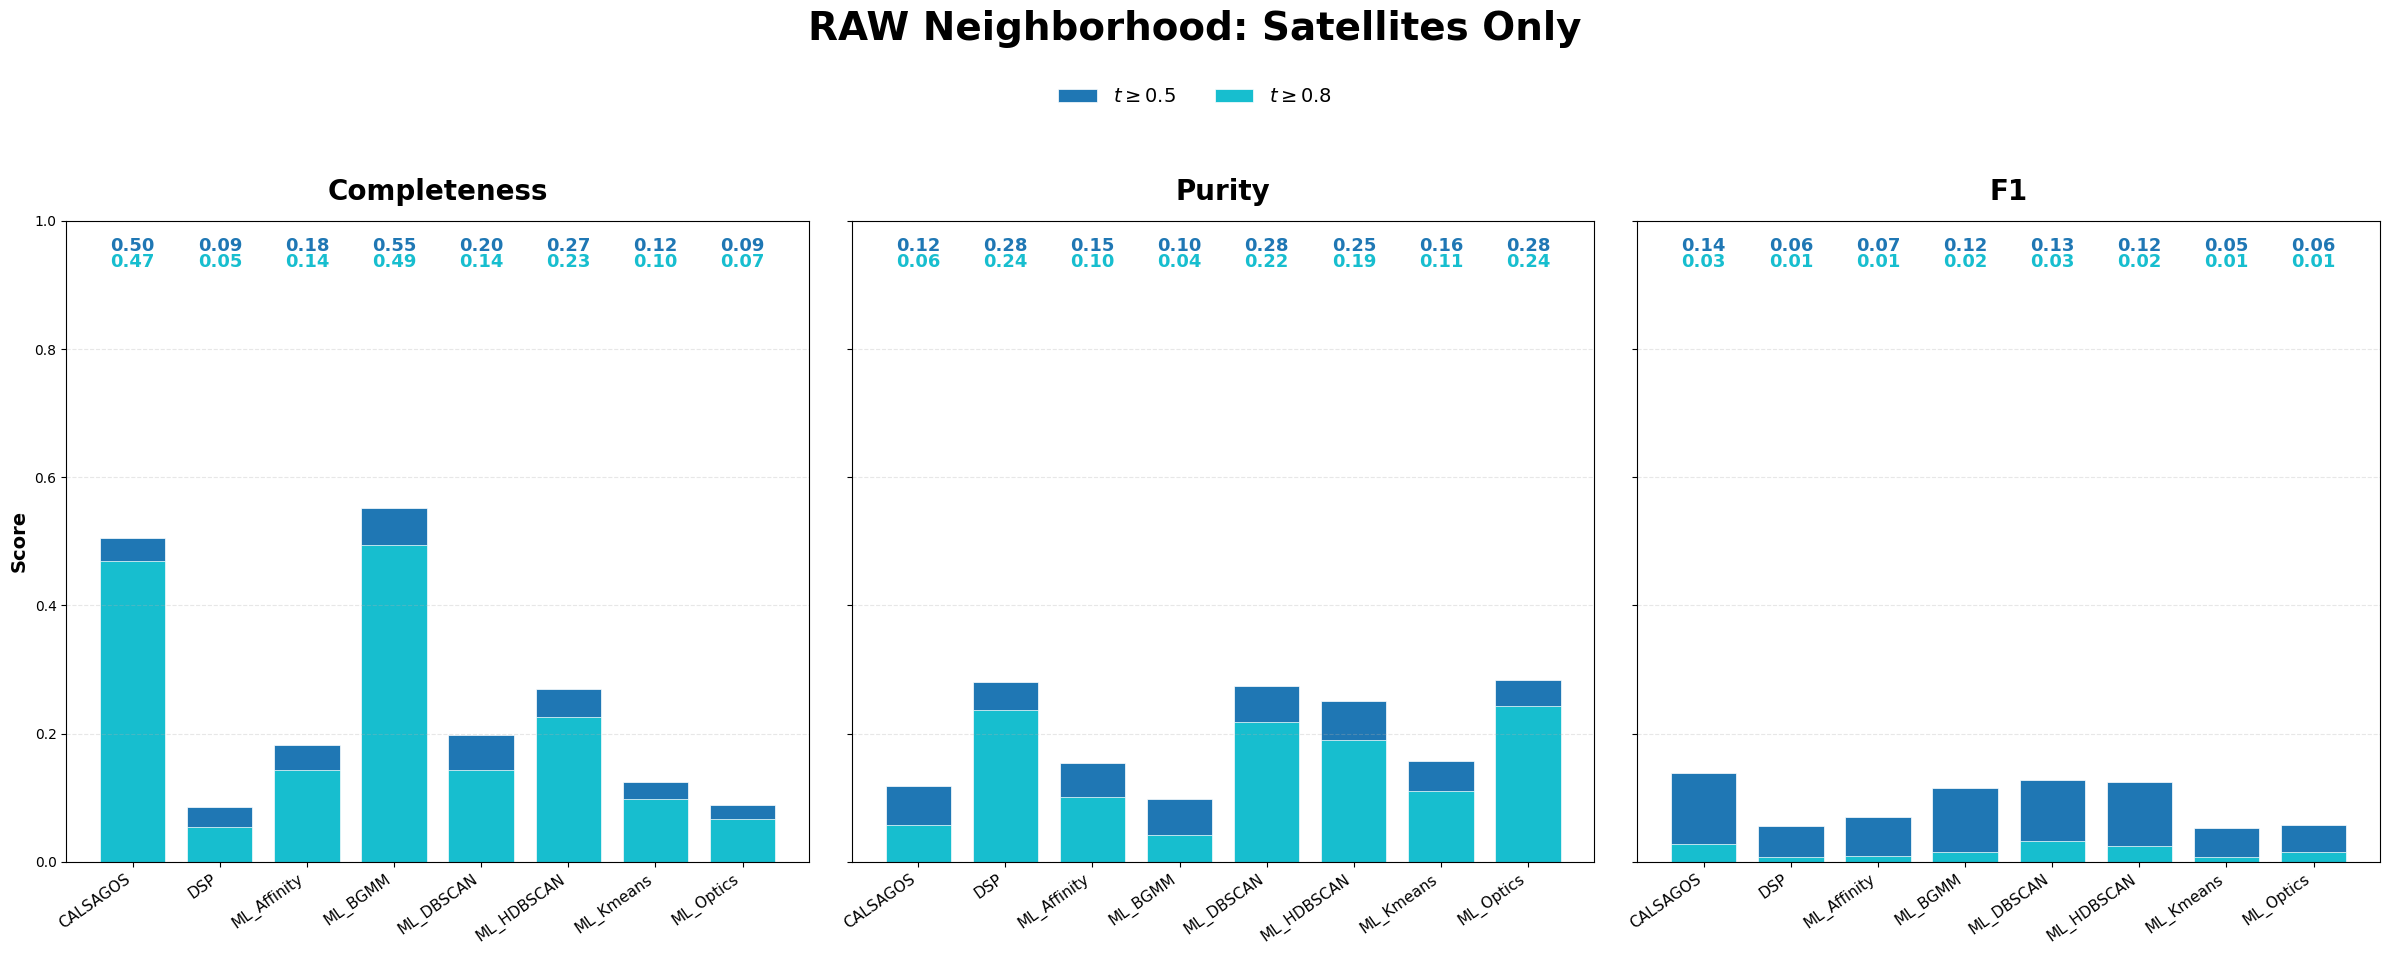

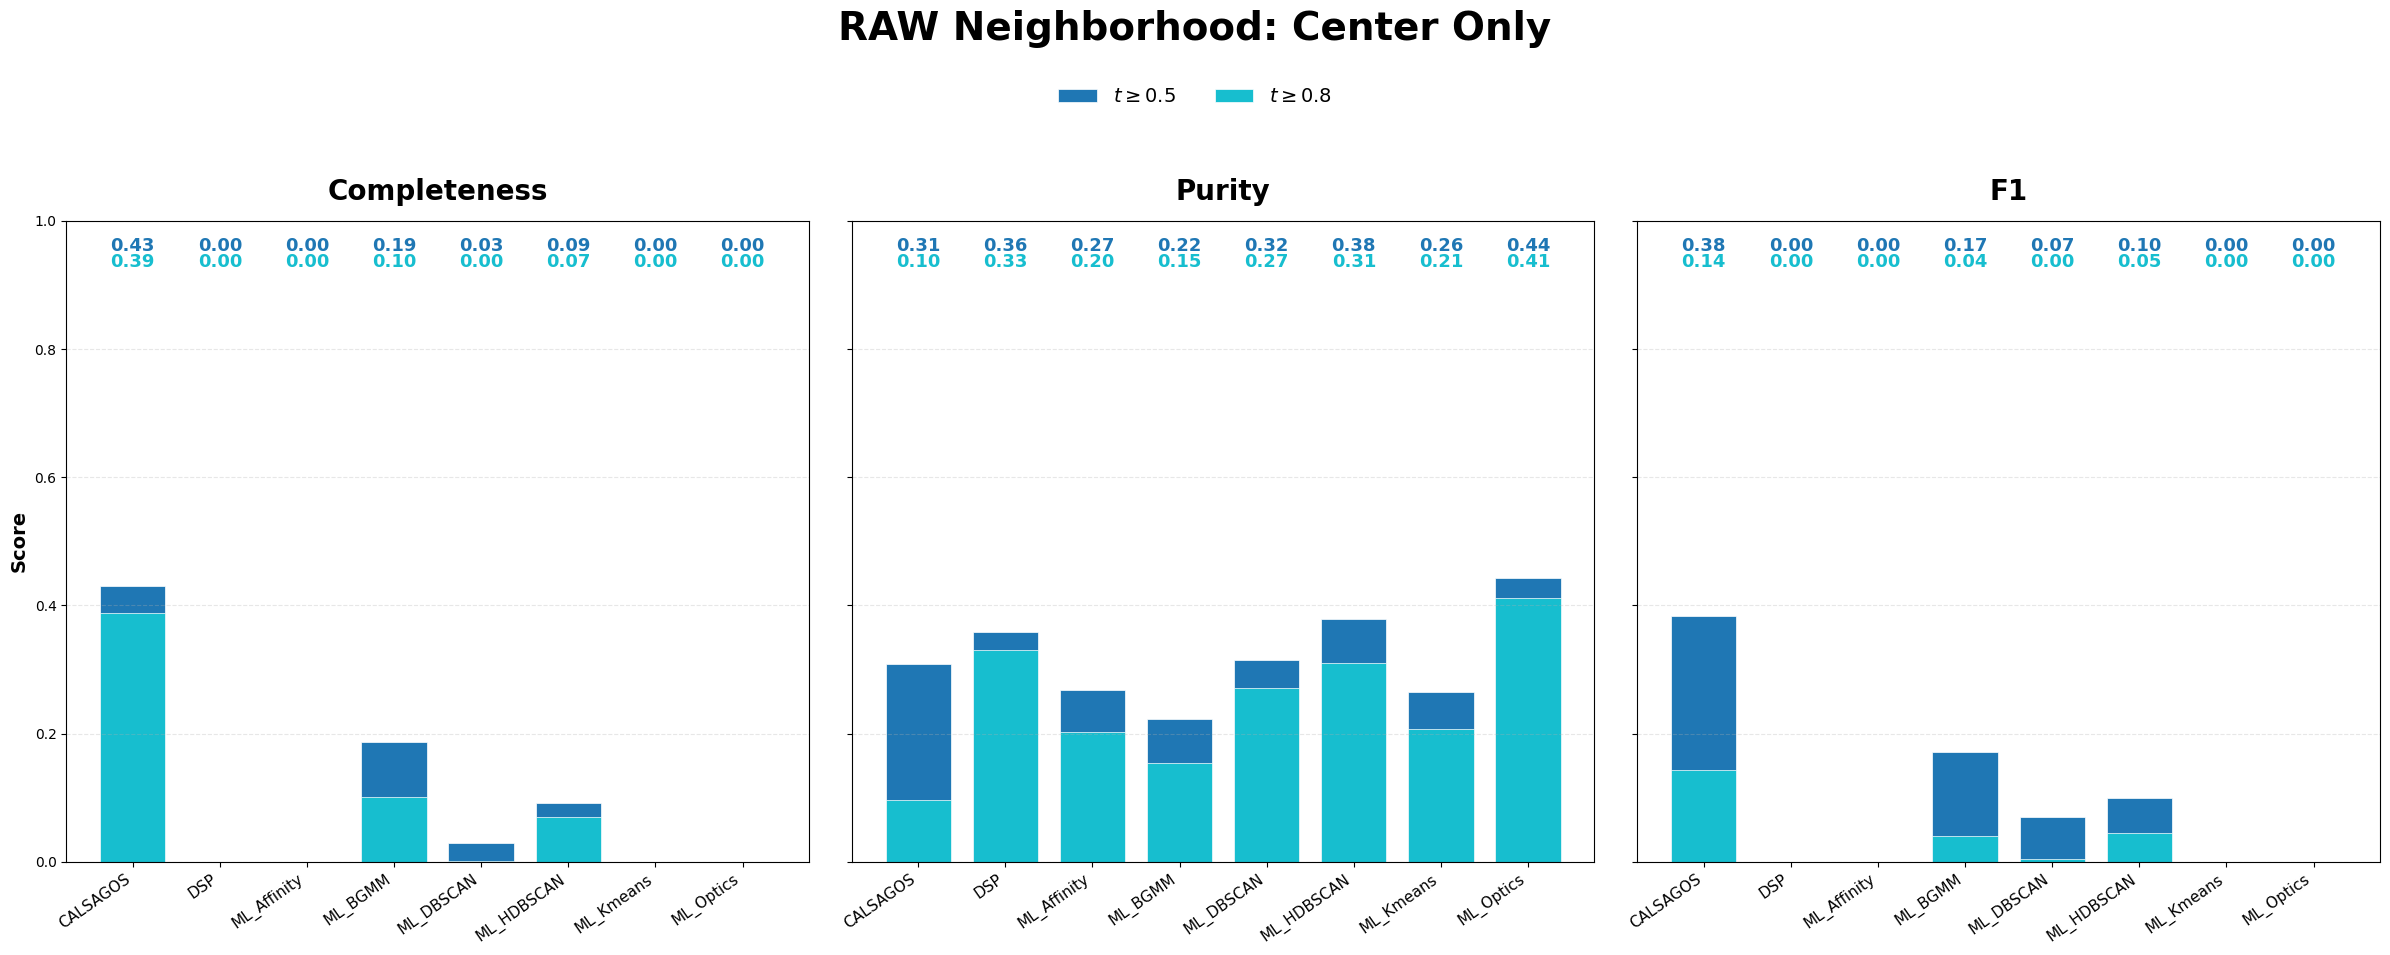

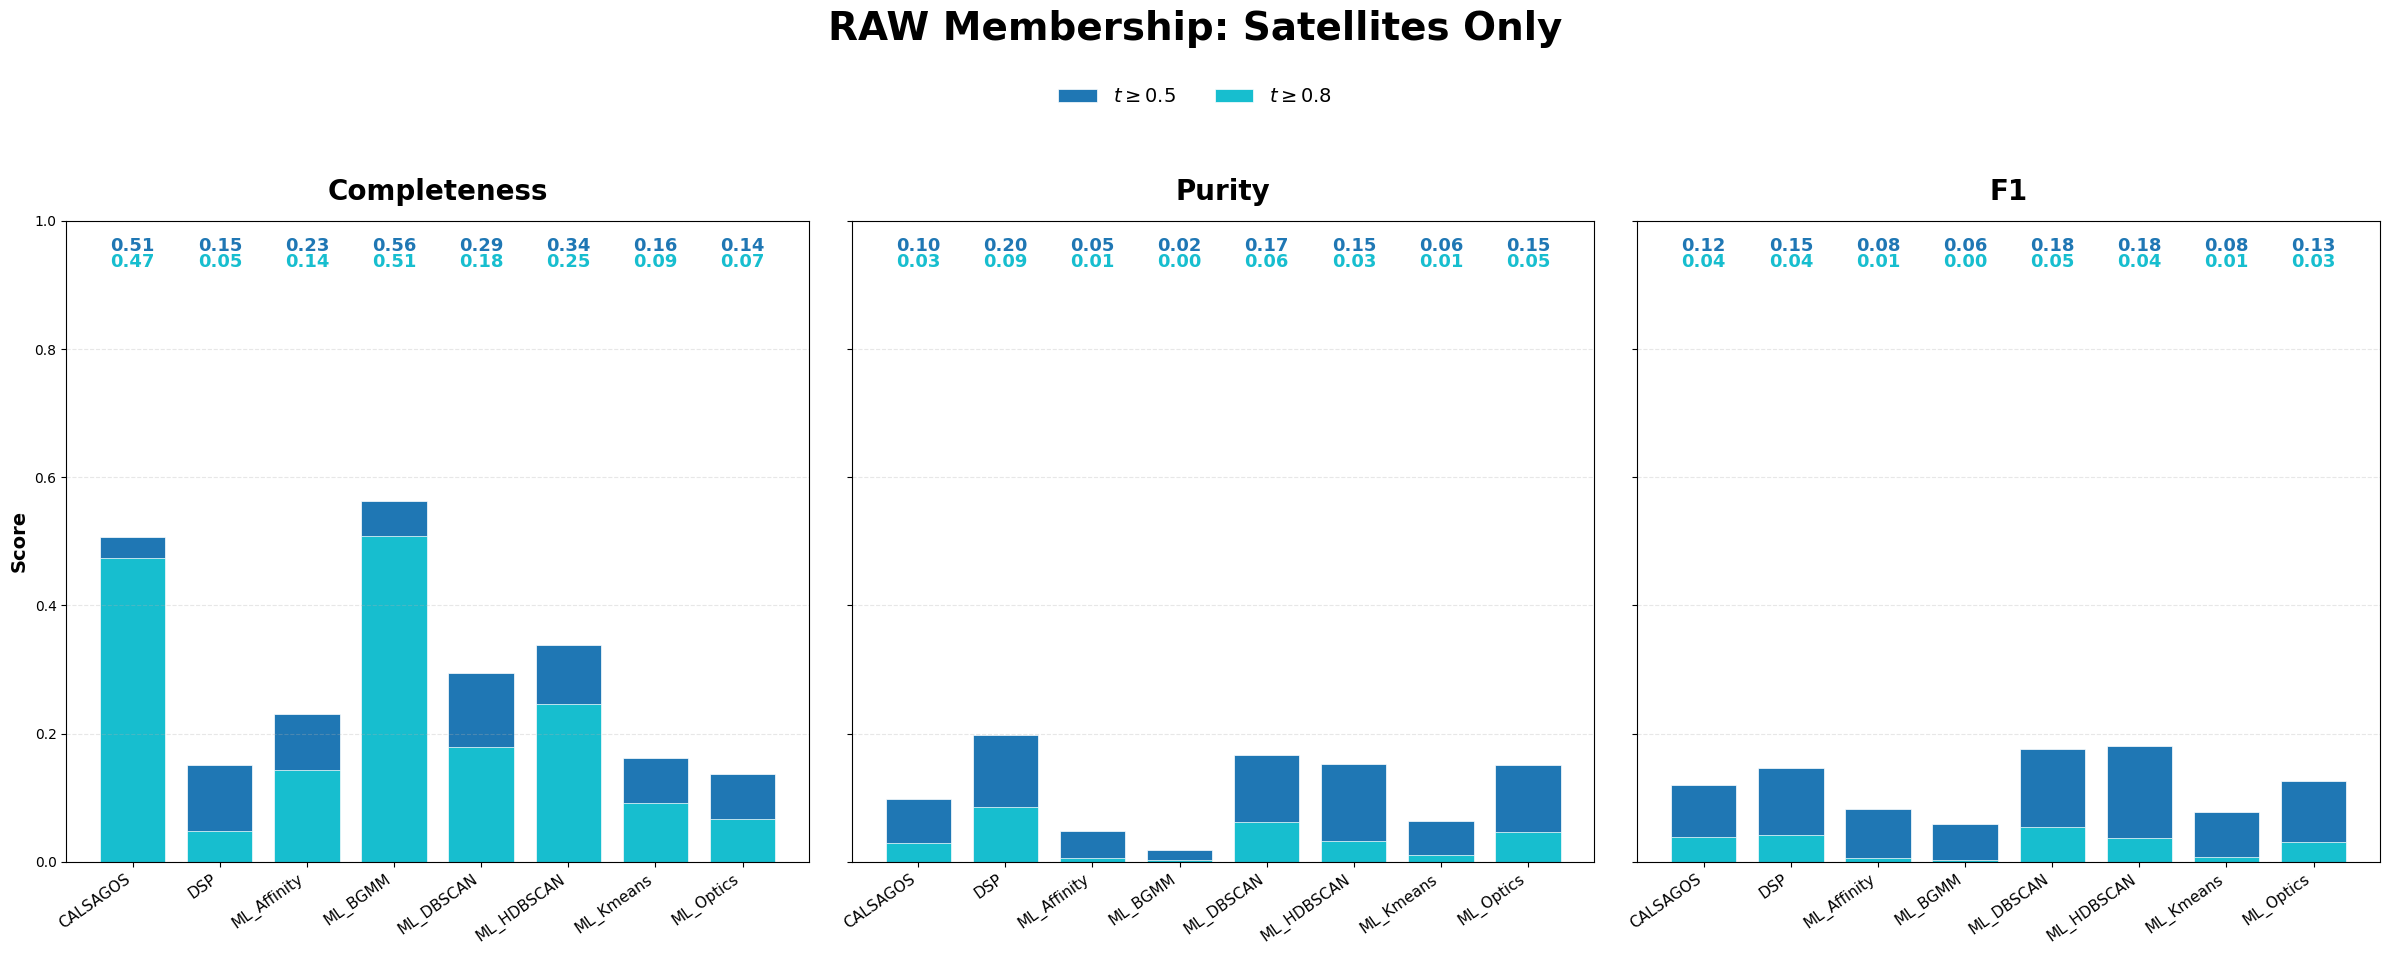

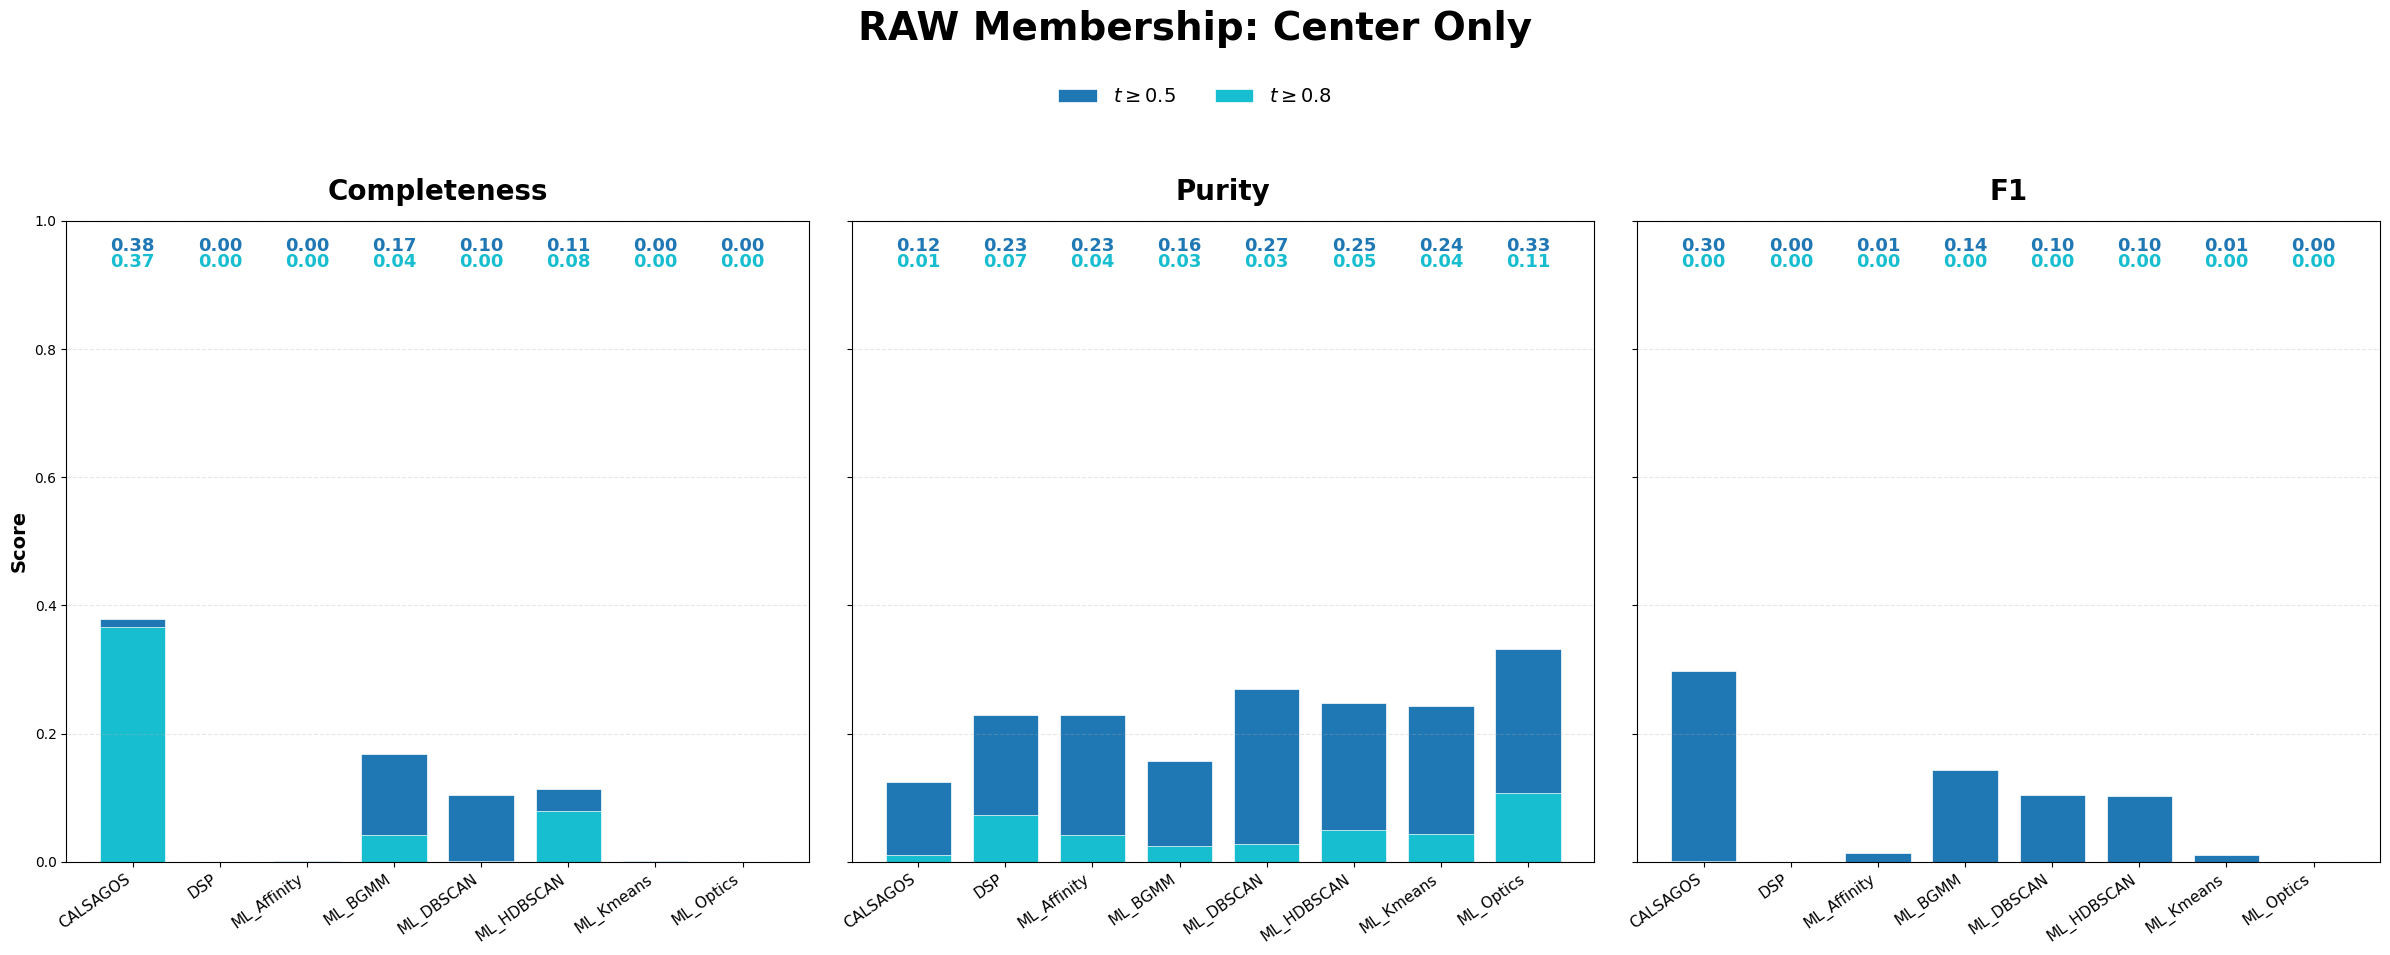

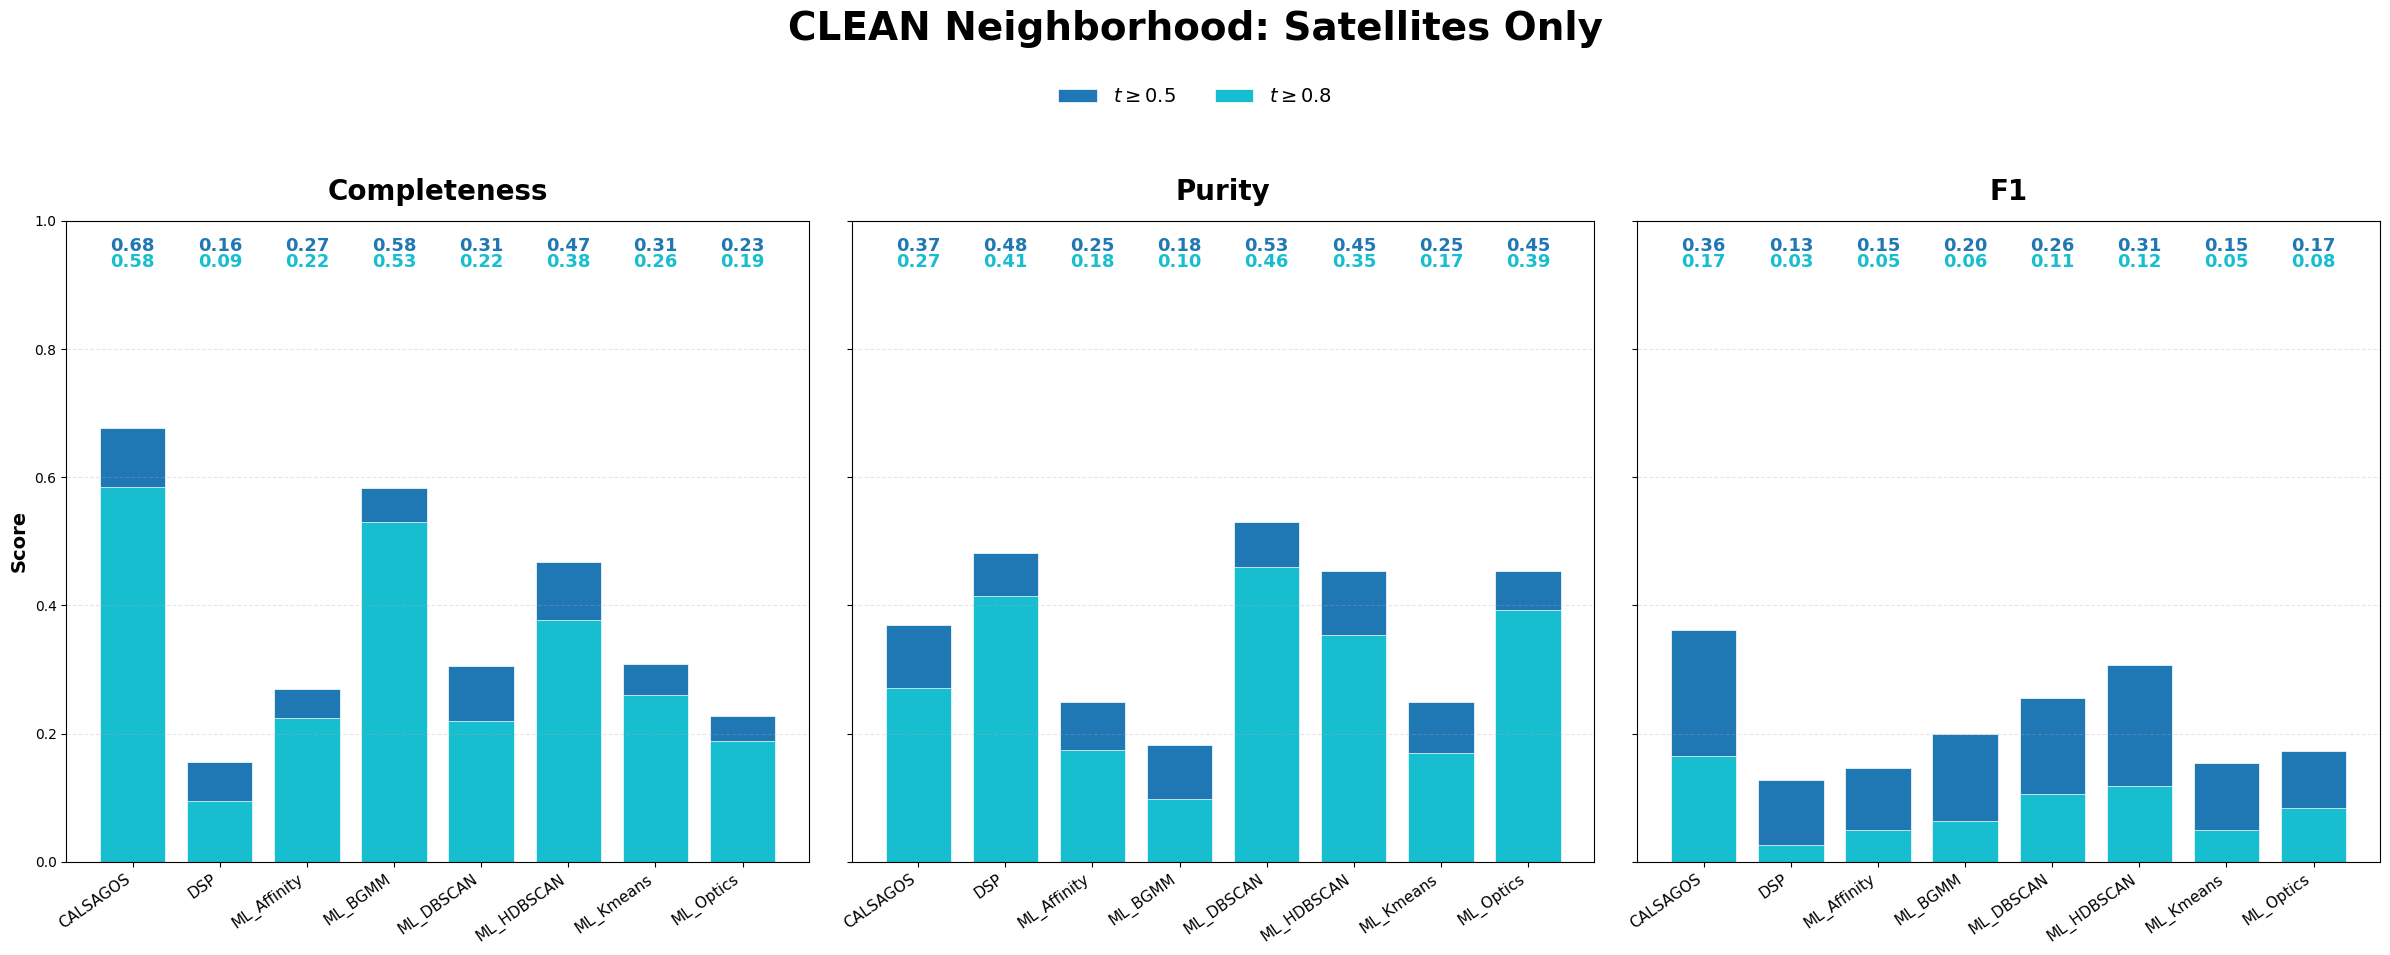

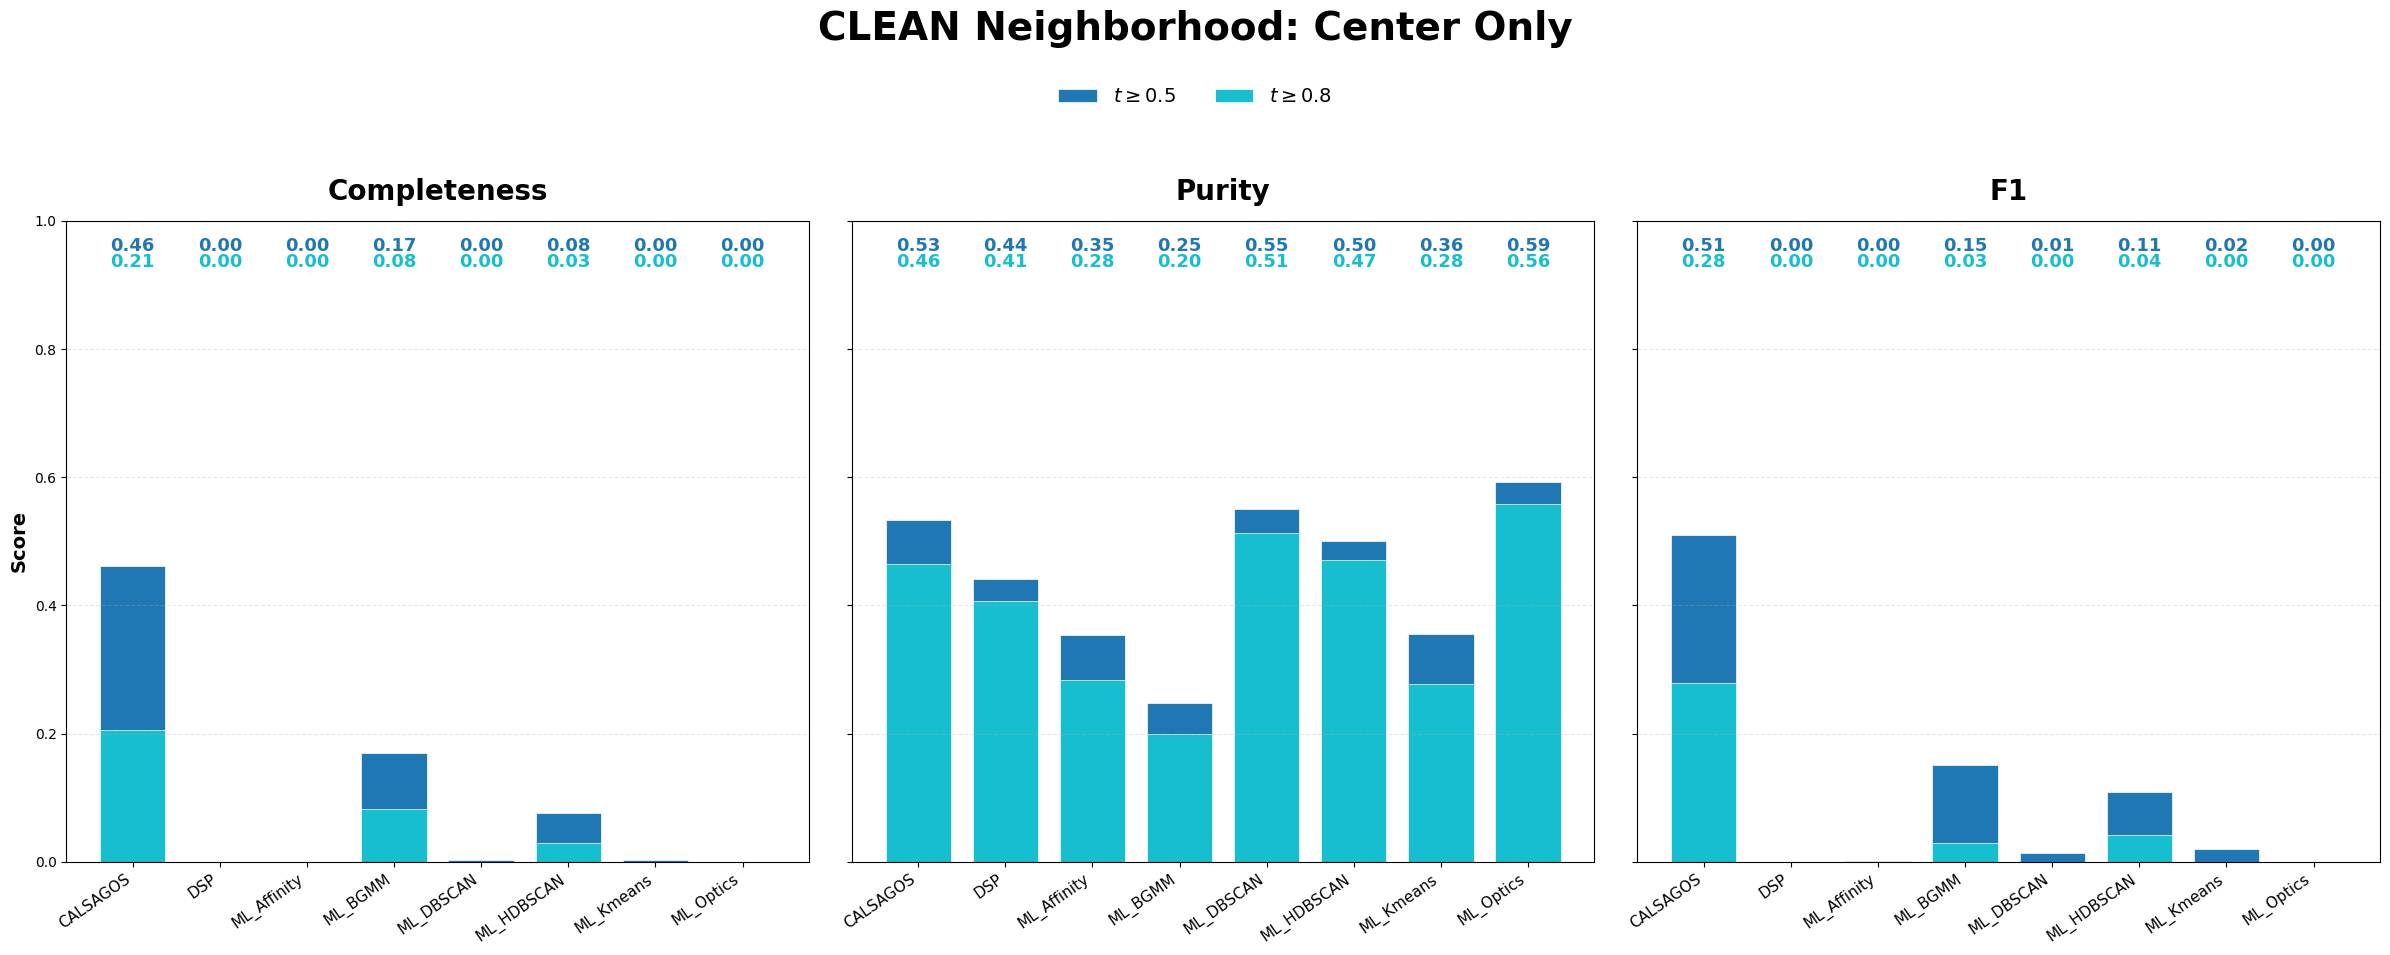

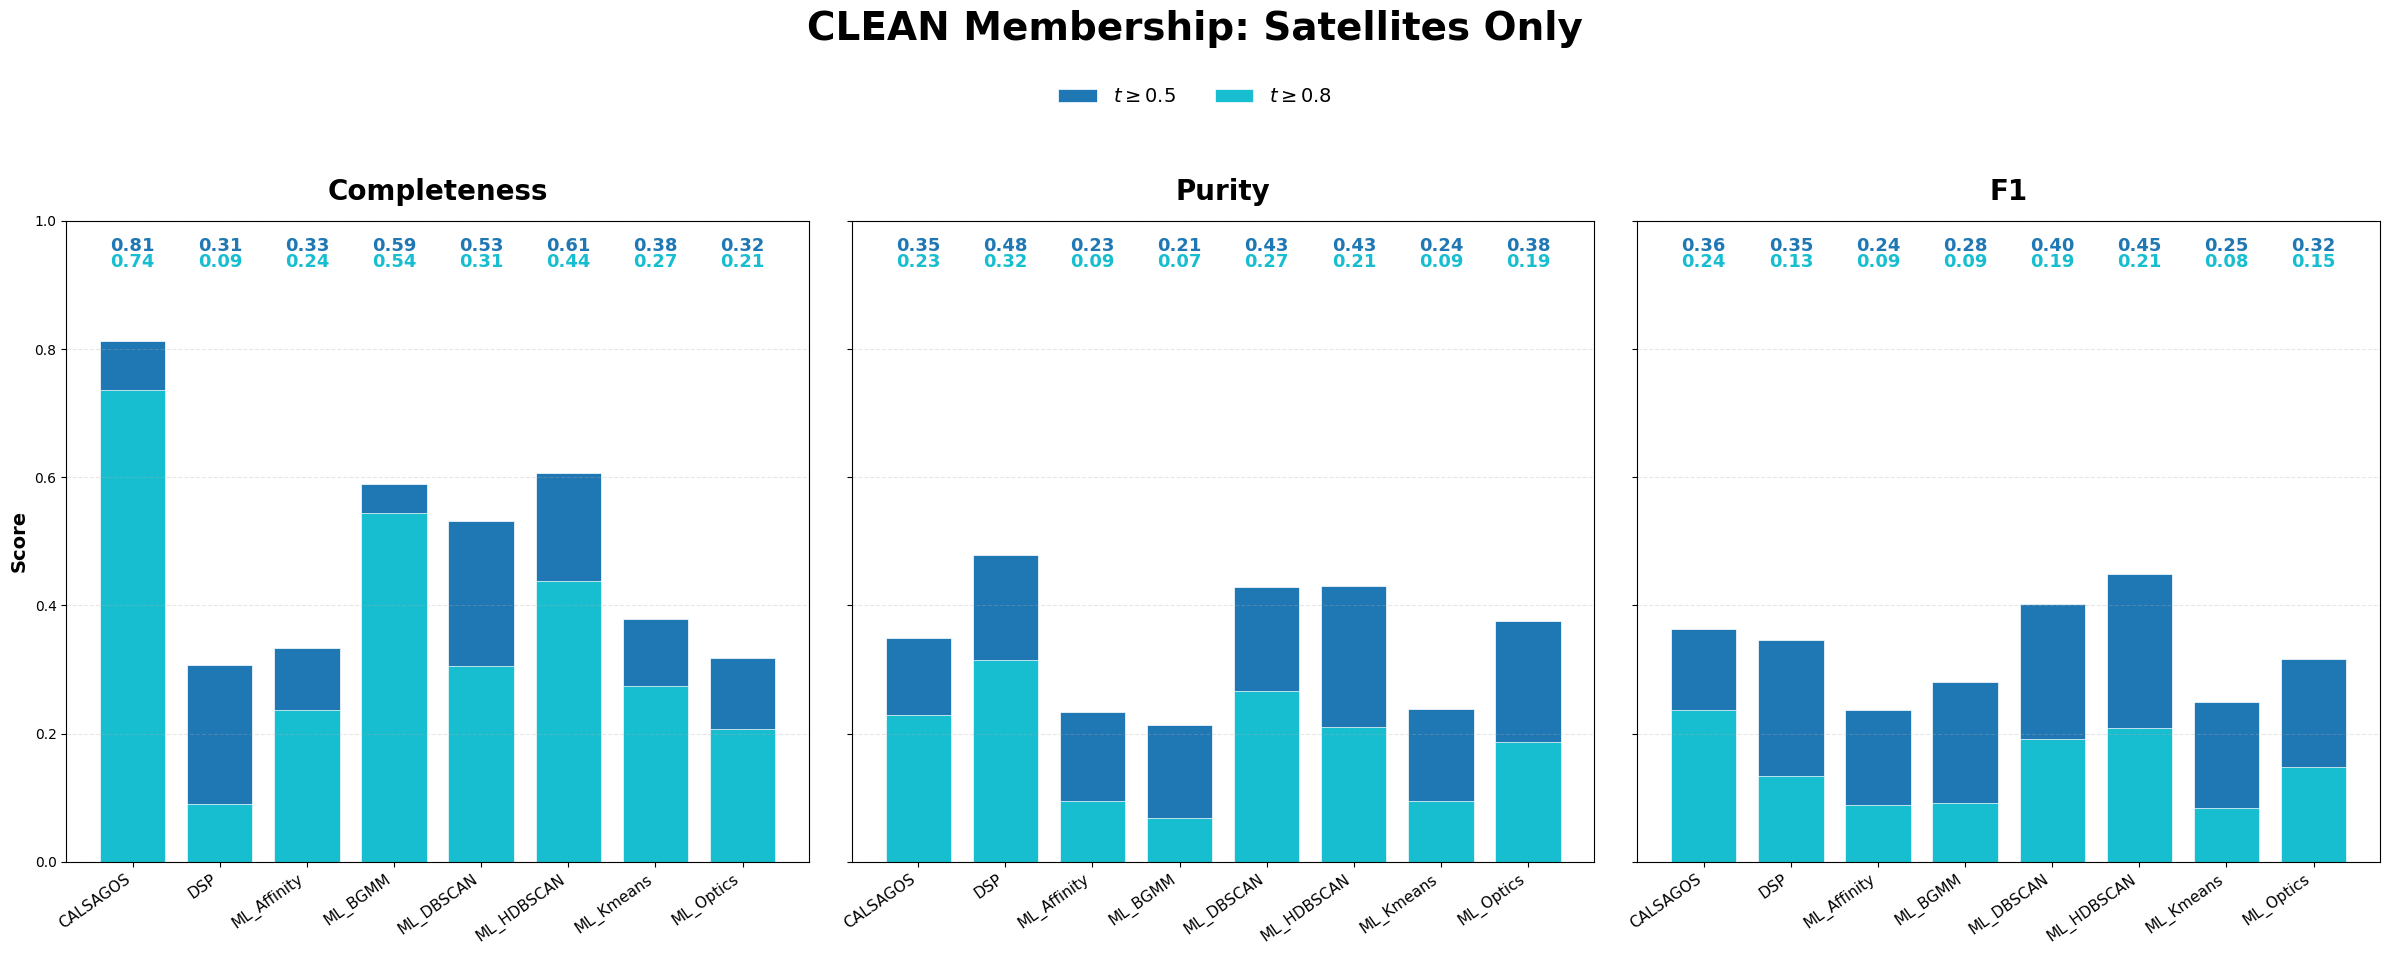

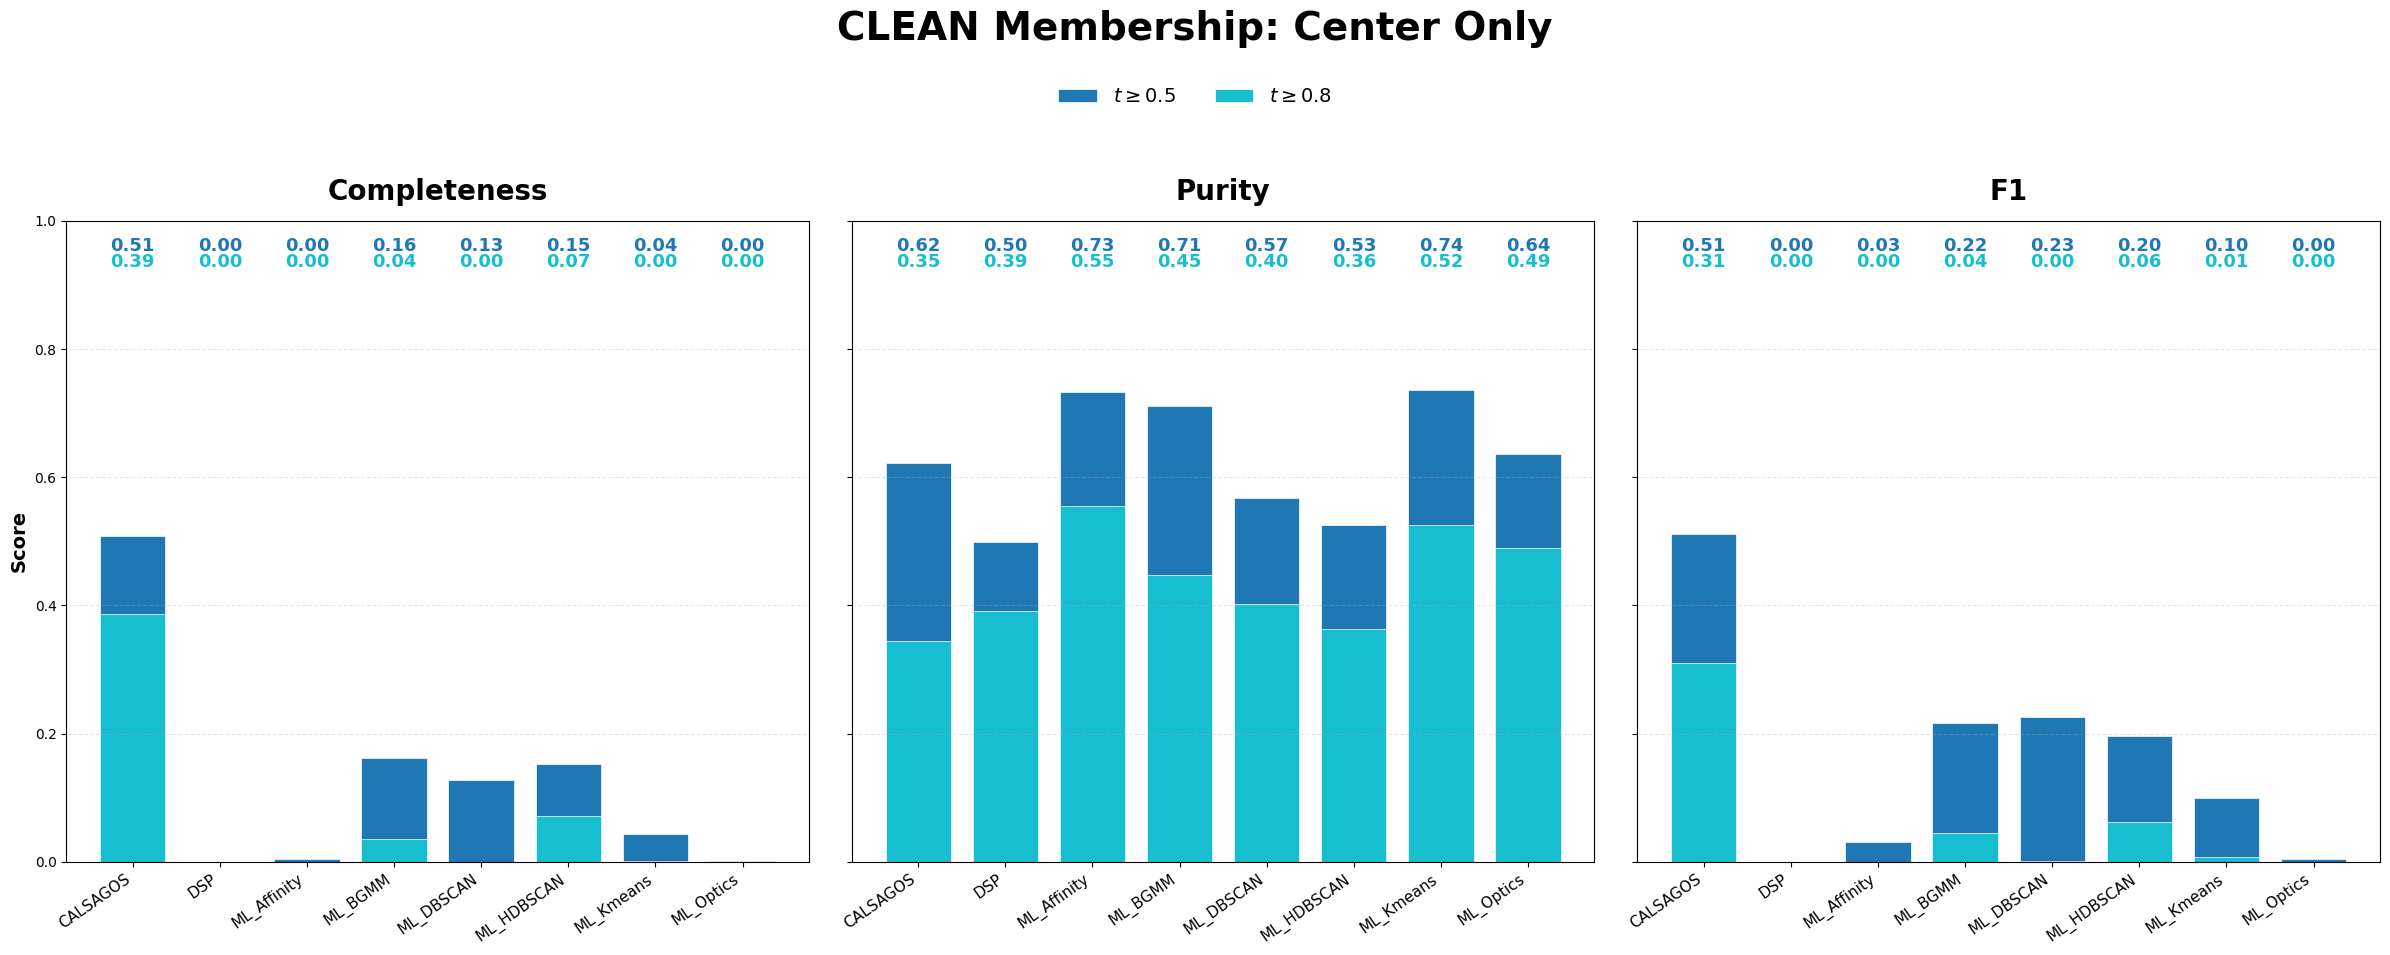

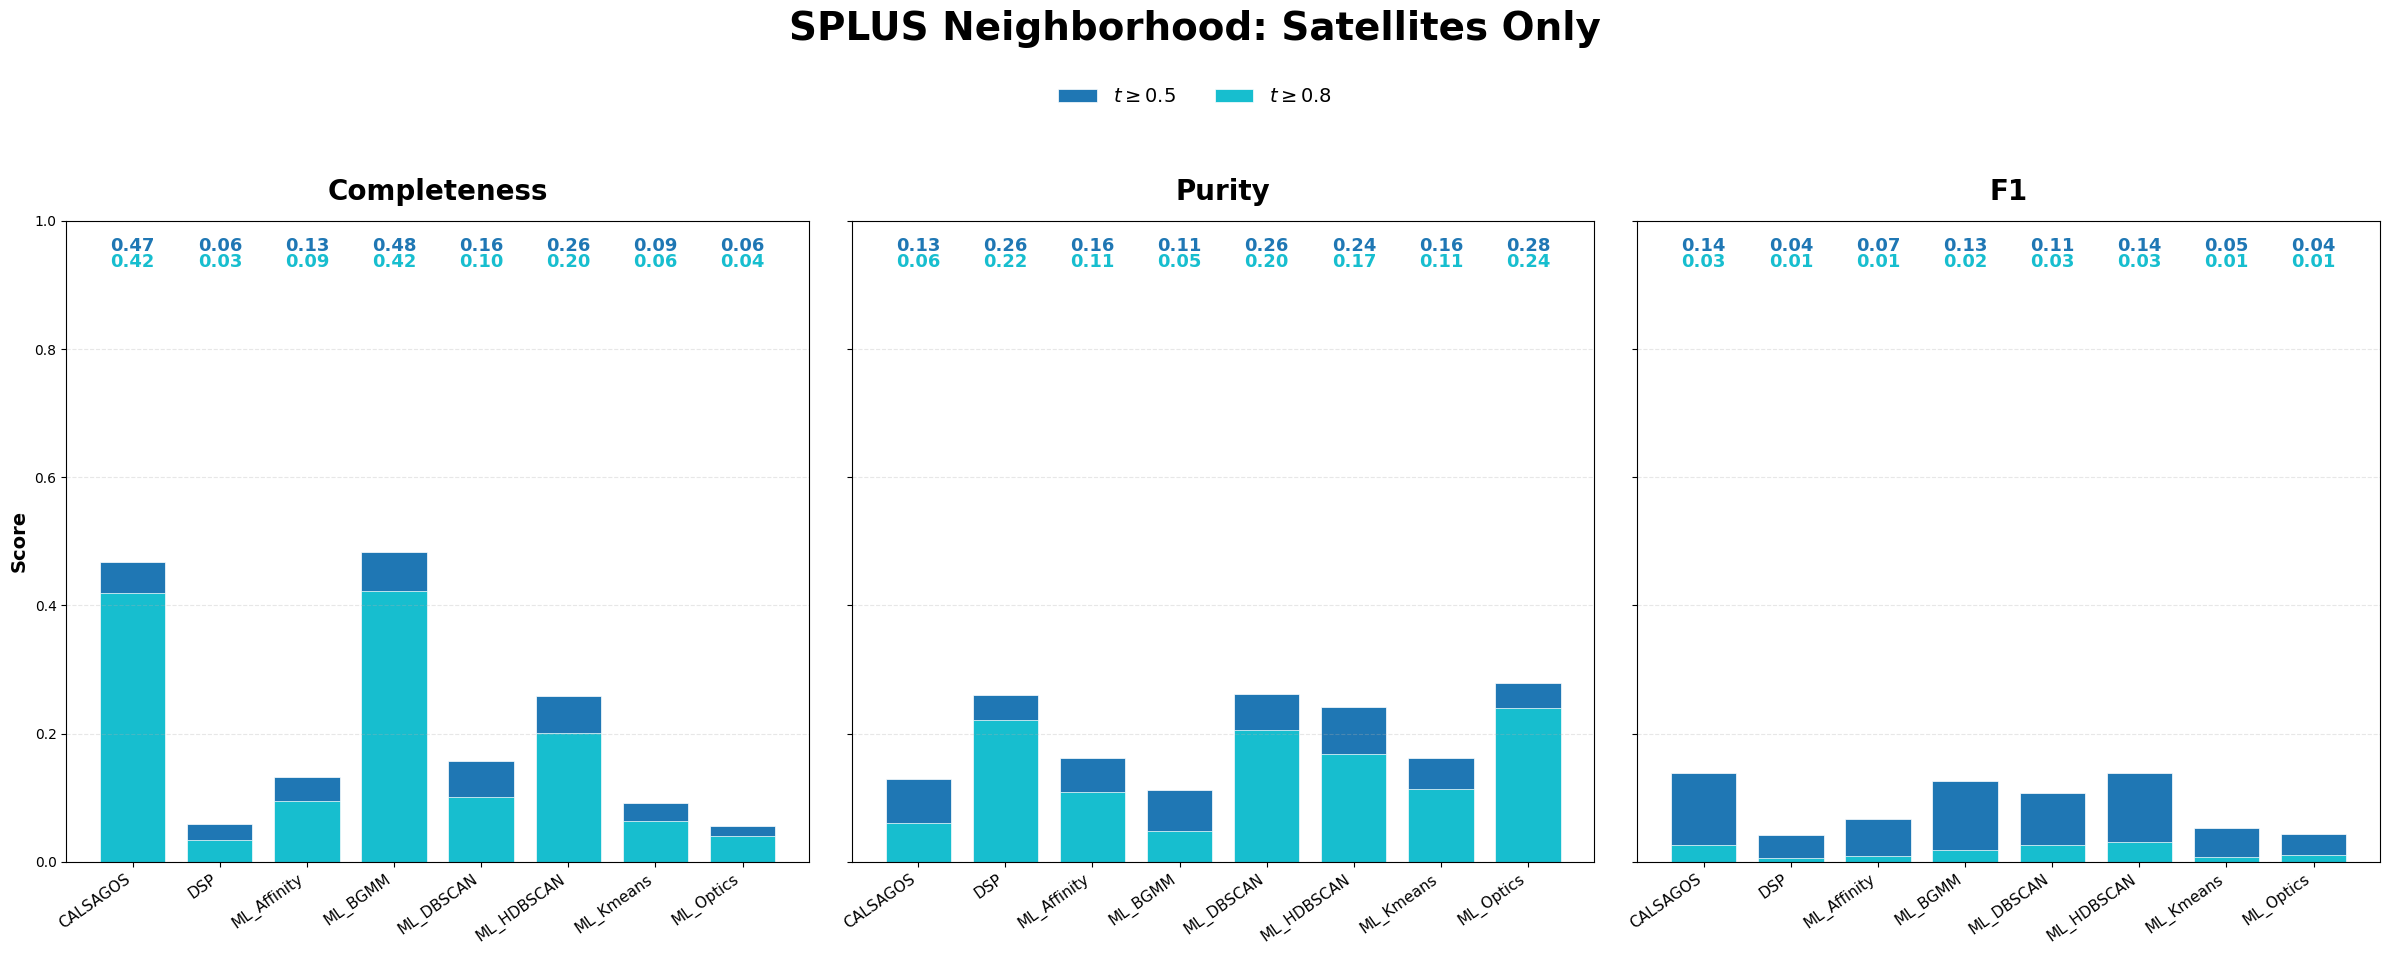

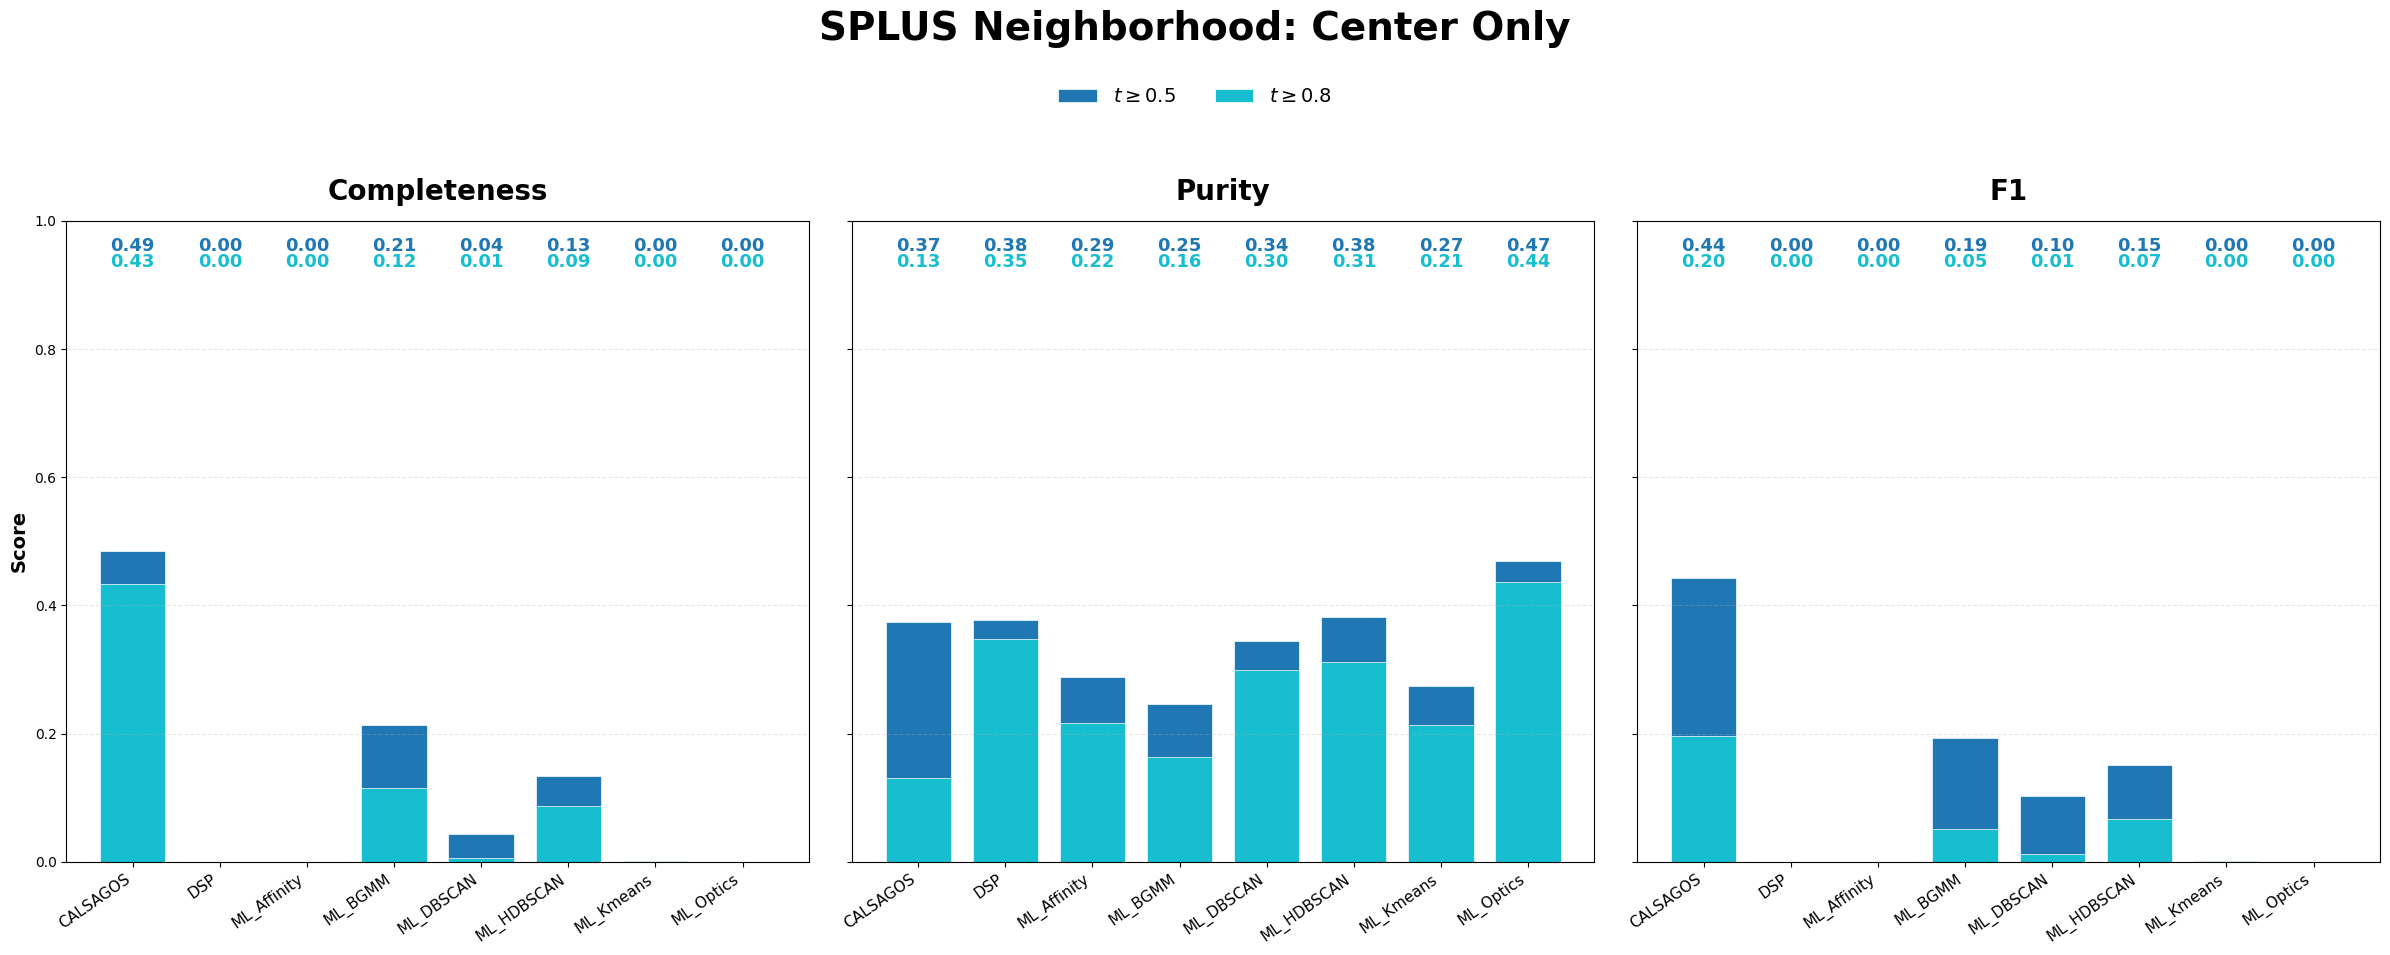

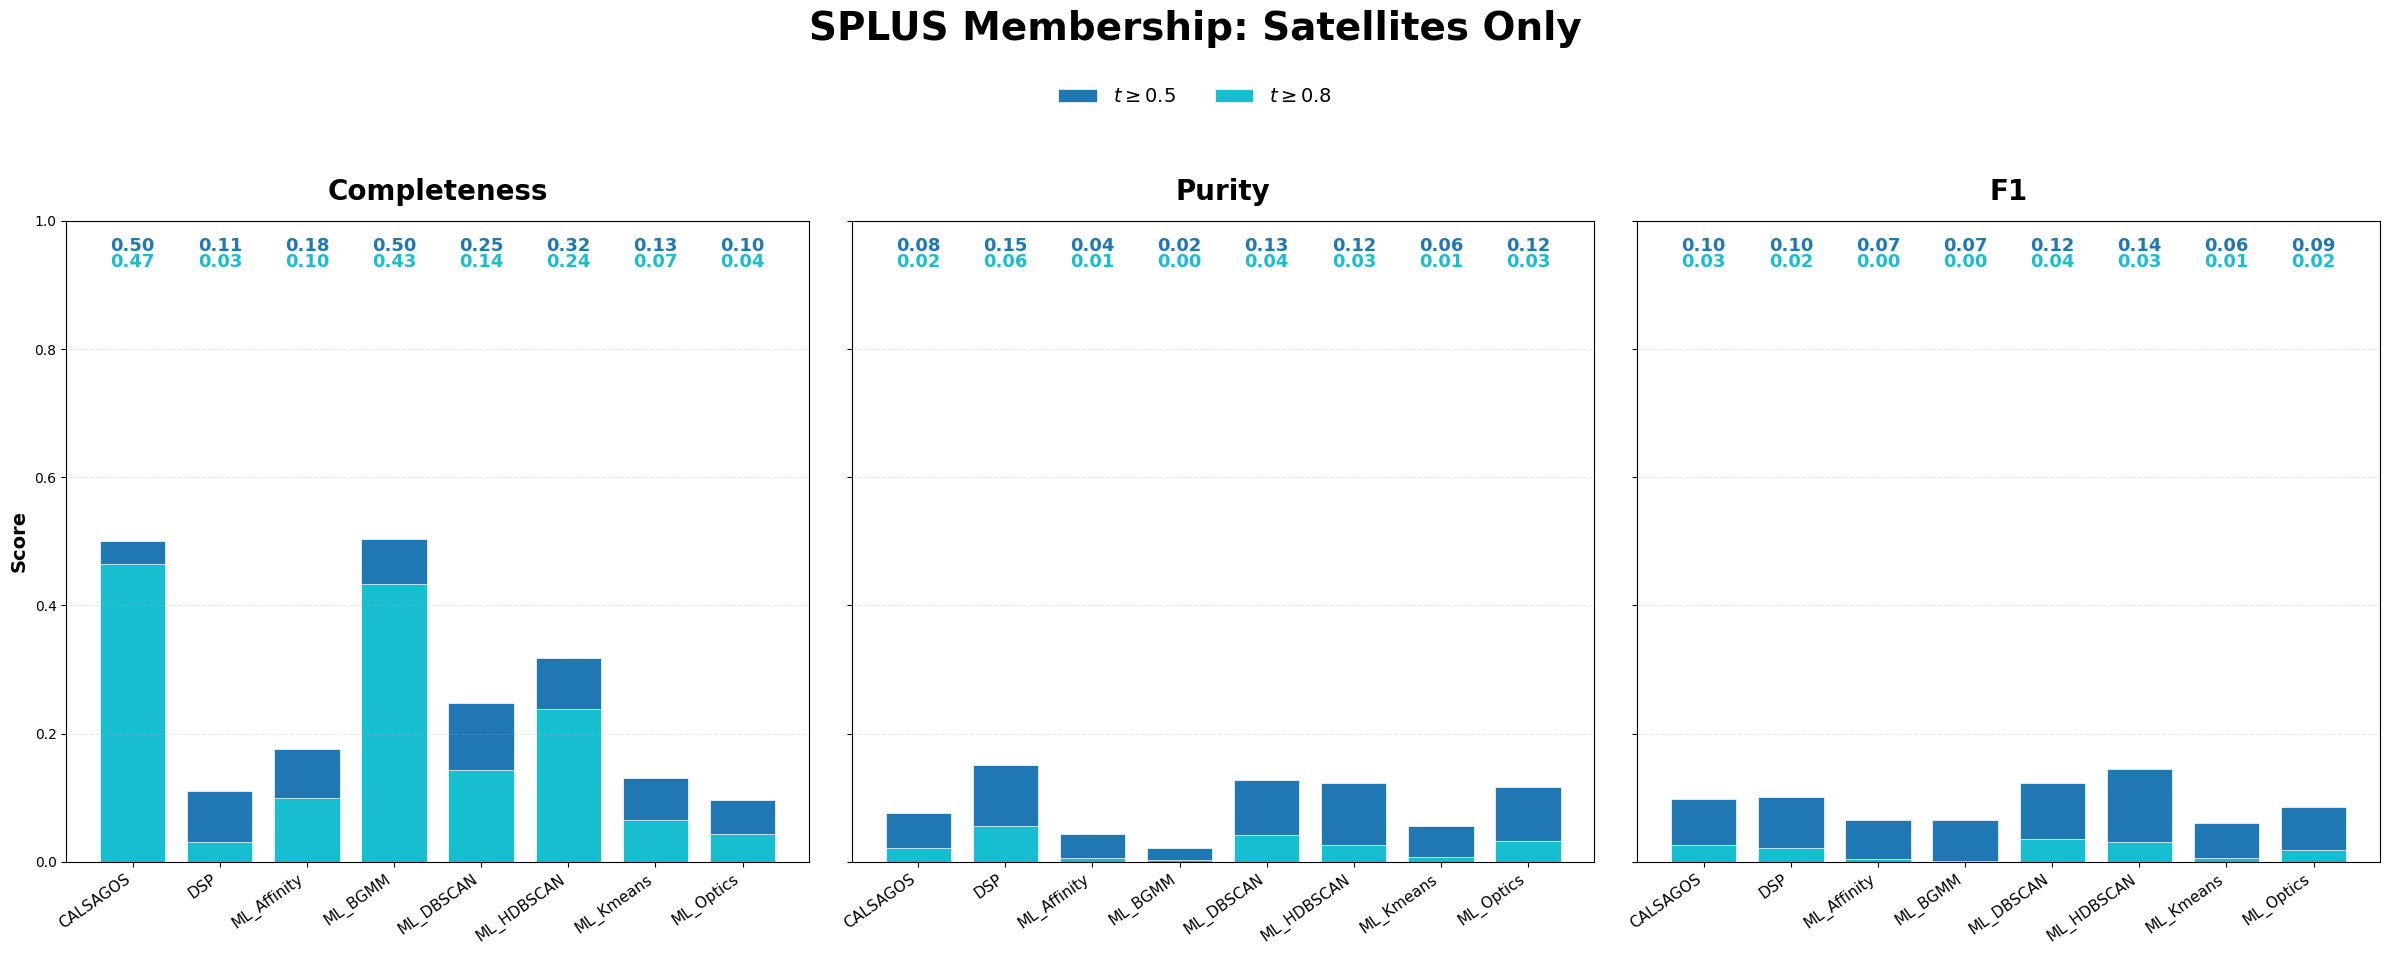

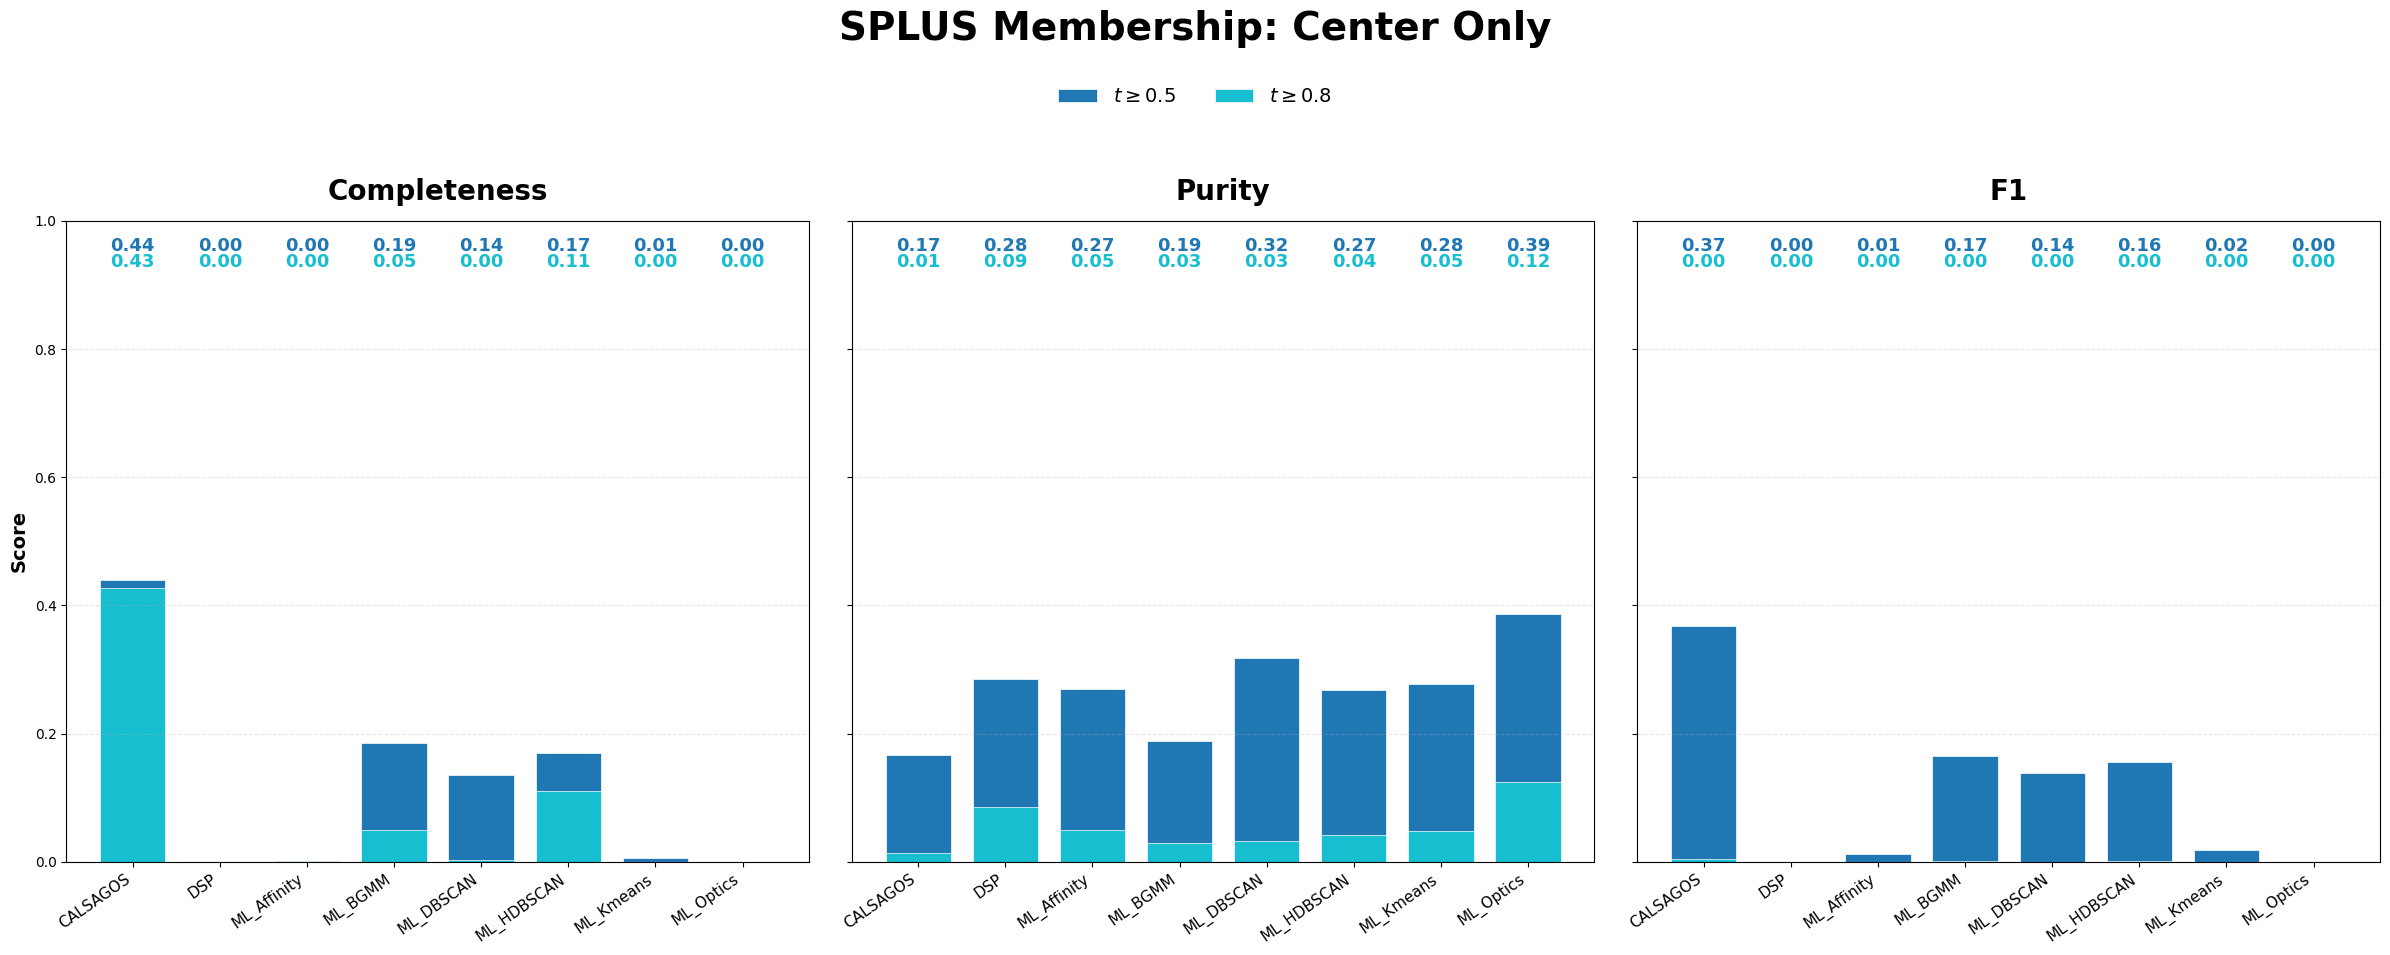

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plot_maker as pm

# --- CONFIG ---
keys = ["Raw","Clean","SPLUS"]
modes = ["satellites", "center"]

metric_trios = [
    ("Neighborhood", ["N_Completeness", "N_Purity", "N_F1"]),
    ("Membership", ["M_Completeness", "M_Purity", "M_F1"])
]

methods_order = sorted([
    "CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics",
    "ML_Kmeans", "ML_Affinity", "ML_BGMM", "ML_Aglomerative"
])

titles_map = {
    "all": "All Data",
    "no-noise": "No Single Galaxies",
    "satellites": "Satellites Only",
    "center": "Center Only"
}

thresholds = [0.5, 0.8]


# --- PLOT ---
for key in keys:
    for trio_name, metrics in metric_trios:
        for mode in modes:

            fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)
            something_plotted = False

            for i, metric in enumerate(metrics):
                file_path = f"Metrics/{metric}/{key}/{mode}_pred_gradient_AVG.pkl"

                if not os.path.exists(file_path):
                    print(f"Missing: {file_path}")
                    continue

                with open(file_path, "rb") as f:
                    data = pickle.load(f)

                df = pd.DataFrame(data).T

                fig, ax, plotted = pm.gradient_bar_plot(
                    df=df,
                    metric_name=metric,
                    thresholds=thresholds,
                    methods_order=methods_order,
                    ax=axes[i]
                    show_ylabel=(i == 0)
                )

                if plotted:
                    something_plotted = True

            if something_plotted:
                fig.suptitle(
                    f"{key.upper()} {trio_name}: {titles_map[mode]}",
                    fontsize=28,
                    fontweight="bold",
                    y=0.98
                )

                handles, labels = axes[0].get_legend_handles_labels()
                unique = dict(zip(labels, handles))

                fig.legend(
                    unique.values(),
                    unique.keys(),
                    loc="upper center",
                    bbox_to_anchor=(0.5, 0.92),
                    ncol=len(thresholds),
                    frameon=False,
                    fontsize=14
                )

                plt.tight_layout(rect=[0, 0.03, 1, 0.88])

                save_dir = f"Images/{key}/{trio_name}/"
                os.makedirs(save_dir, exist_ok=True)

                thresholds_tag = "_".join(str(t).replace(".", "") for t in thresholds)
                save_path = f"{save_dir}{mode}_t{thresholds_tag}.png"

                plt.savefig(save_path, dpi=300, bbox_inches="tight")
                plt.show()
            else:
                plt.close(fig)

In [6]:
import numpy as np
import pickle
import os
from scipy.stats import spearmanr

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]
dist_metric = "Distance"
correlation_metric_name = "S_Correlation"

all_methods = sorted([
    "CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics",
    "ML_Kmeans", "ML_Affinity", "ML_GMM", "ML_Aglomerative"
])

def process_inhomogeneous_matrices(matrix_list, has_noise):
    """
    Handles a list of 10 matrices where the number of columns varies.
    Returns a single flattened array of all 'real halo' entries.
    """
    flat_values = []
    for exec_matrix in matrix_list:
        m_arr = np.array(exec_matrix)
        # Slicing: Strip Row 0 (Noise) if applicable
        m_real = m_arr[1:, :] if has_noise else m_arr
        flat_values.extend(m_real.flatten())
    return np.array(flat_values)

# --- EXECUTION ---
for metric in source_metrics:
    for key in keys:
        has_noise = (key != "Clean")
        metric_path = f"Metrics/{metric}/{key}/results.pkl"
        dist_path = f"Metrics/{dist_metric}_Mpc/{key}/results.pkl"
        
        if not os.path.exists(metric_path) or not os.path.exists(dist_path):
            continue
            
        with open(metric_path, "rb") as f: m_data = pickle.load(f)
        with open(dist_path, "rb") as f: d_data = pickle.load(f)

        method_results = {}
        for method in all_methods:
            if method not in m_data or method not in d_data: continue
            
            all_m = []
            all_d = []
            
            # h_id is the cluster ID
            for h_id in m_data[method].keys():
                if h_id not in d_data[method]: continue
                
                # Extract and flatten all 10 executions for this specific cluster
                m_flat = process_inhomogeneous_matrices(m_data[method][h_id], has_noise)
                d_flat = process_inhomogeneous_matrices(d_data[method][h_id], has_noise)
                
                # Check that they match (they should, as they represent the same True Halos)
                if len(m_flat) == len(d_flat):
                    all_m.extend(m_flat)
                    all_d.extend(d_flat)

            # Final correlation for the method across the entire 700-cluster pool
            all_m = np.array(all_m)
            all_d = np.array(all_d)
            
            # Spearman mask: F1 > 0 and Distance >= 0
            mask = (all_m > 0) & (all_d >= 0)
            
            if np.sum(mask) >= 10: # Increased threshold for statistical significance
                rho, p = spearmanr(all_d[mask], all_m[mask])
                method_results[method] = {"rho": rho, "p": p}
                print(f"[{key} | {metric}] {method}: rho={rho:.3f}")

        # SAVE
        out_dir = f"Metrics/{correlation_metric_name}/{key}"
        os.makedirs(out_dir, exist_ok=True)
        save_path = f"{out_dir}/no-noise_{metric}_vs_MpcDist.pkl"
        with open(save_path, "wb") as f:
            pickle.dump(method_results, f)

[Raw | N_F1] CALSAGOS: rho=-0.456
[Raw | N_F1] DSP: rho=-0.367
[Raw | N_F1] ML_Affinity: rho=-0.483
[Raw | N_F1] ML_DBSCAN: rho=-0.650
[Raw | N_F1] ML_HDBSCAN: rho=-0.535
[Raw | N_F1] ML_Kmeans: rho=-0.600
[Raw | N_F1] ML_Optics: rho=-0.415
[Clean | N_F1] CALSAGOS: rho=-0.613
[Clean | N_F1] DSP: rho=-0.389
[Clean | N_F1] ML_Affinity: rho=-0.541
[Clean | N_F1] ML_DBSCAN: rho=-0.664
[Clean | N_F1] ML_HDBSCAN: rho=-0.617
[Clean | N_F1] ML_Kmeans: rho=-0.585
[Clean | N_F1] ML_Optics: rho=-0.474
[SPLUS | N_F1] CALSAGOS: rho=-0.501
[SPLUS | N_F1] DSP: rho=-0.355
[SPLUS | N_F1] ML_Affinity: rho=-0.572
[SPLUS | N_F1] ML_DBSCAN: rho=-0.642
[SPLUS | N_F1] ML_HDBSCAN: rho=-0.535
[SPLUS | N_F1] ML_Kmeans: rho=-0.636
[SPLUS | N_F1] ML_Optics: rho=-0.372
[Raw | M_F1] CALSAGOS: rho=-0.552
[Raw | M_F1] DSP: rho=-0.694
[Raw | M_F1] ML_Affinity: rho=-0.704
[Raw | M_F1] ML_DBSCAN: rho=-0.760
[Raw | M_F1] ML_HDBSCAN: rho=-0.736
[Raw | M_F1] ML_Kmeans: rho=-0.789
[Raw | M_F1] ML_Optics: rho=-0.690
[Clean |

In [8]:
import numpy as np
import pickle
import os

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]
dist_metric = "Distance"
all_methods = sorted(["CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics", "ML_Kmeans", "ML_Affinity", "ML_GMM", "ML_Aglomerative"])

for metric in source_metrics:
    for key in keys:
        has_noise = (key != "Clean")
        m_path = f"Metrics/{metric}/{key}/results.pkl"
        d_path = f"Metrics/{dist_metric}_Mpc/{key}/results.pkl"
        
        if not os.path.exists(m_path) or not os.path.exists(d_path): continue
            
        with open(m_path, "rb") as f: m_data = pickle.load(f)
        with open(d_path, "rb") as f: d_data = pickle.load(f)

        method_scatter_data = {}
        for method in all_methods:
            if method not in m_data or method not in d_data: continue
            
            all_m, all_d = [], []
            for h_id in m_data[method].keys():
                if h_id not in d_data[method]: continue
                
                # --- FIX: Iterate through the 10 executions separately ---
                # This prevents the inhomogeneous NumPy error
                for exec_idx in range(len(m_data[method][h_id])):
                    m_exec = np.array(m_data[method][h_id][exec_idx])
                    d_exec = np.array(d_data[method][h_id][exec_idx])
                    
                    # Slice for no-noise (Remove Row 0 if Raw/SPLUS)
                    m_real = m_exec[1:, :] if has_noise else m_exec
                    d_real = d_exec[1:, :] if has_noise else d_exec
                    
                    # Flatten the matrices for this execution
                    m_flat = m_real.flatten()
                    d_flat = d_real.flatten()
                    
                    # Only take points where algorithm found a cluster (F1 > 0)
                    mask = m_flat > 0
                    all_m.extend(m_flat[mask])
                    all_d.extend(d_flat[mask])
            
            method_scatter_data[method] = {"dist": np.array(all_d), "f1": np.array(all_m)}

        out_dir = f"Metrics/S_Correlation/{key}"
        os.makedirs(out_dir, exist_ok=True)
        save_path = f"{out_dir}/scatter_{metric}_vs_MpcDist.pkl"
        with open(save_path, "wb") as f:
            pickle.dump(method_scatter_data, f)
        print(f"Saved scatter data: {save_path}")

Saved scatter data: Metrics/S_Correlation/Raw/scatter_N_F1_vs_MpcDist.pkl
Saved scatter data: Metrics/S_Correlation/Clean/scatter_N_F1_vs_MpcDist.pkl
Saved scatter data: Metrics/S_Correlation/SPLUS/scatter_N_F1_vs_MpcDist.pkl
Saved scatter data: Metrics/S_Correlation/Raw/scatter_M_F1_vs_MpcDist.pkl
Saved scatter data: Metrics/S_Correlation/Clean/scatter_M_F1_vs_MpcDist.pkl
Saved scatter data: Metrics/S_Correlation/SPLUS/scatter_M_F1_vs_MpcDist.pkl


In [4]:
import importlib
importlib.reload(pm)

<module 'plot_maker' from '/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py'>

Graph generated: MpcOffset_F1_Degradation_M_F1_SPLUS.png


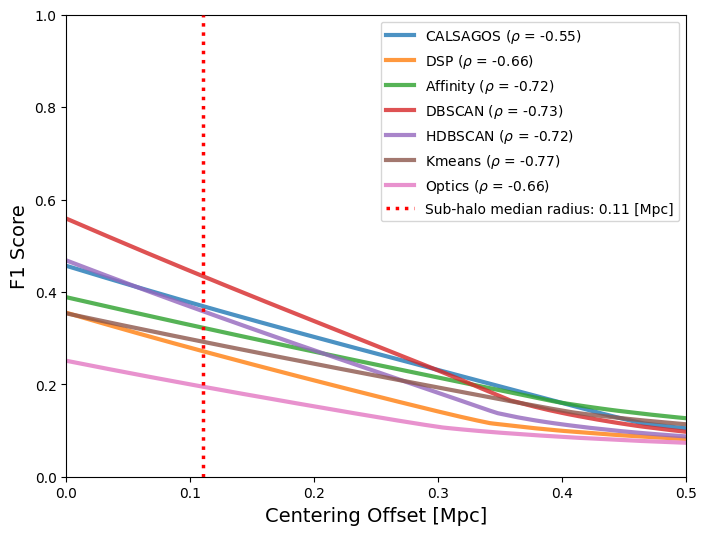

In [7]:
import os
import pickle
import matplotlib.pyplot as plt
import plot_maker as pm

# --- CONFIG ---
keys = ["SPLUS"]
source_metrics = ["M_F1"]

save_dir = "Images/F1_Offset_Degradation"
os.makedirs(save_dir, exist_ok=True)

# --- MAIN LOOP ---
for metric in source_metrics:
    for key in keys:
        
        file_path = f"Metrics/S_Correlation/{key}/scatter_{metric}_vs_MpcDist.pkl"
        if not os.path.exists(file_path):
            continue

        with open(file_path, "rb") as f:
            data = pickle.load(f)

        fig, ax = pm.offset_f1_degradation(data, xlim=(0, 0.5), x_unit="Mpc", plot_sigma=False, plot_median=False)

        ax.axvline(
                0.11,
                color="red",
                linestyle=":",
                linewidth=2.5,
                label=f"Sub-halo median radius: 0.11 [Mpc]",
                zorder=5
            )

        ax.legend()

        filename = f"MpcOffset_F1_Degradation_{metric}_{key}.png"
        plt.savefig(f"{save_dir}/{filename}", dpi=300, bbox_inches="tight")
        print(f"Graph generated: {filename}")
        plt.show()

In [19]:
import importlib
importlib.reload(pm)

<module 'plot_maker' from '/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py'>

Saved: Images/Radial_Proficiency/Raw_N_F1_Radial.png


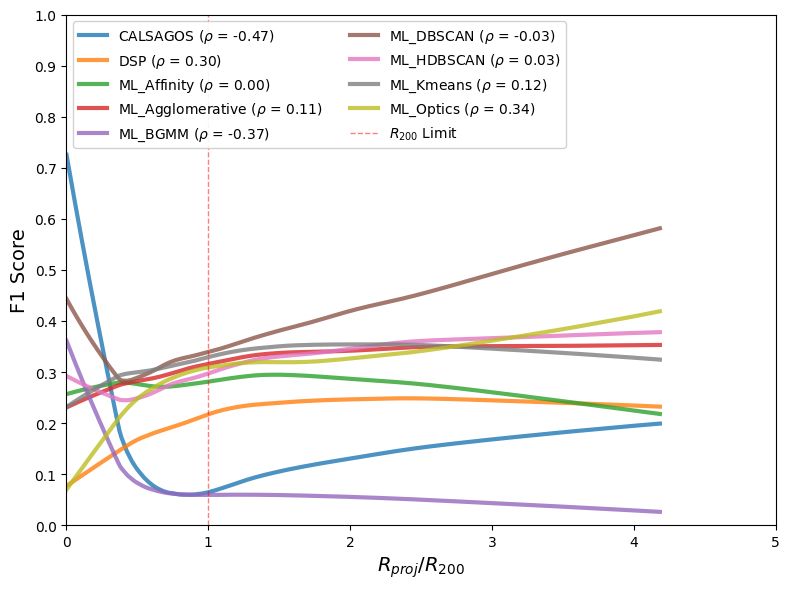

Saved: Images/Radial_Proficiency/Clean_N_F1_Radial.png


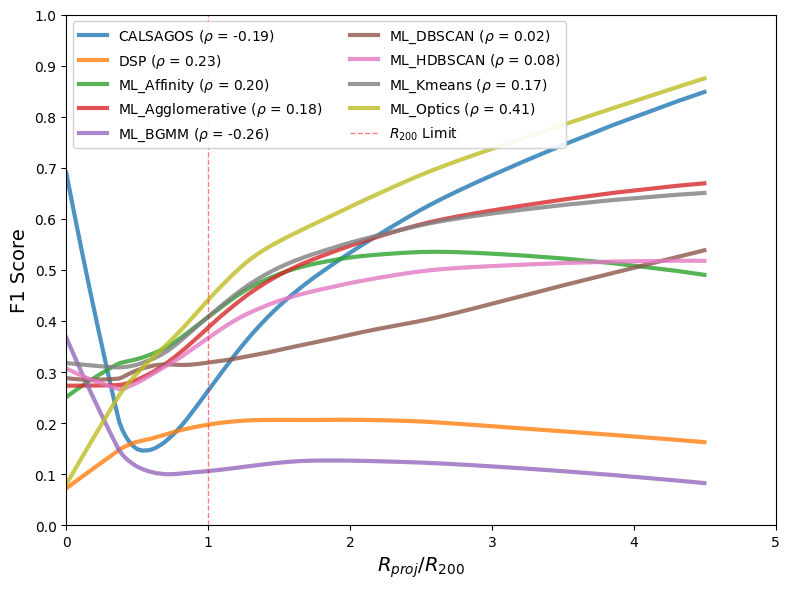

Saved: Images/Radial_Proficiency/SPLUS_N_F1_Radial.png


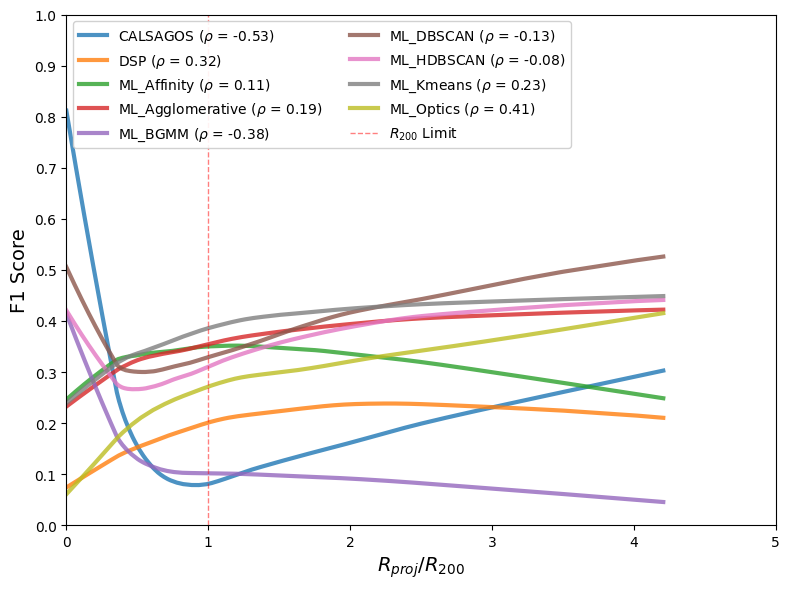

Saved: Images/Radial_Proficiency/Raw_M_F1_Radial.png


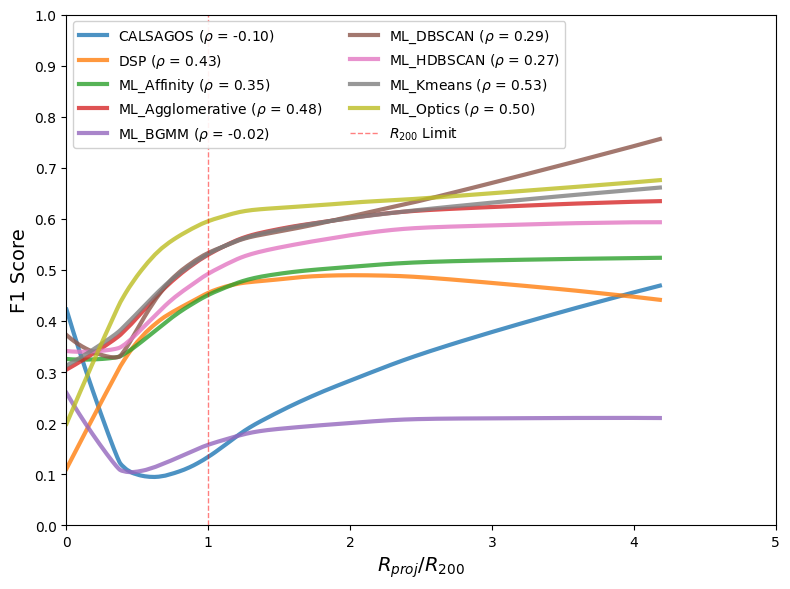

Saved: Images/Radial_Proficiency/Clean_M_F1_Radial.png


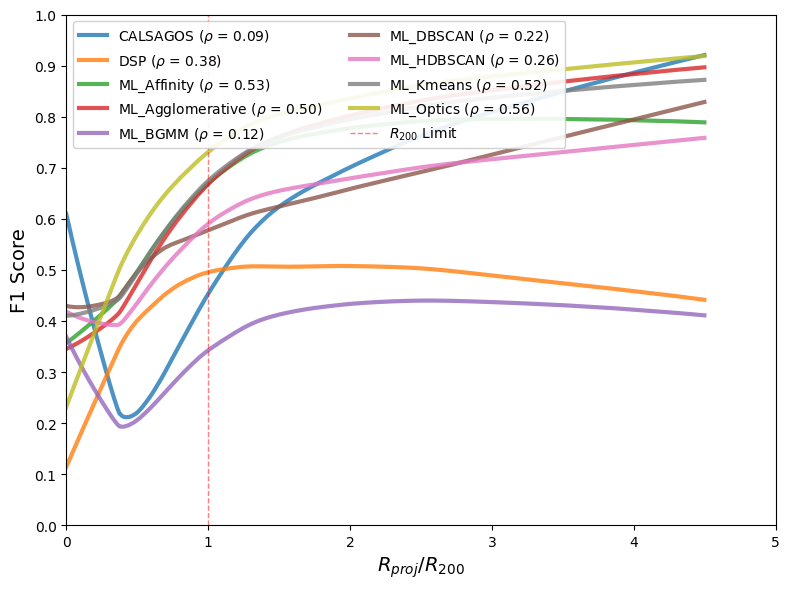

Saved: Images/Radial_Proficiency/SPLUS_M_F1_Radial.png


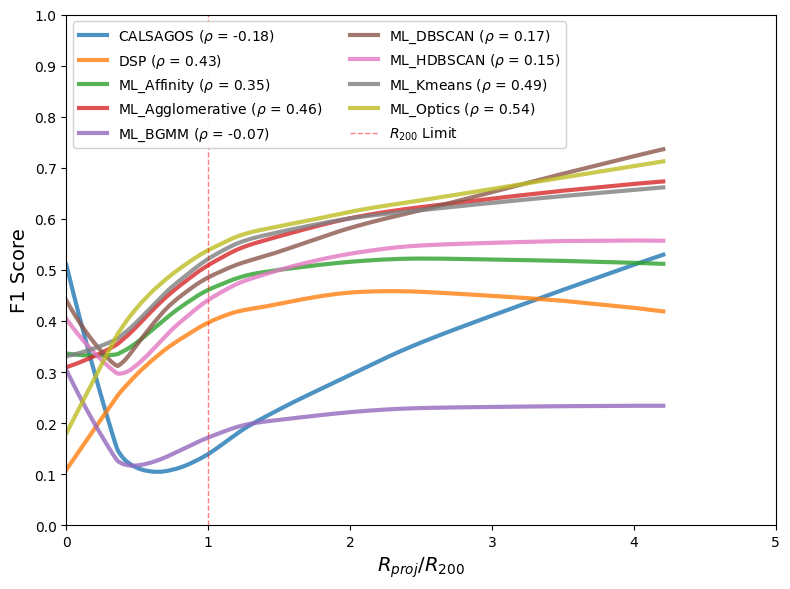

In [20]:
import matplotlib.pyplot as plt
import pickle
import os
import plot_maker as pm

keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]

titles_map = {
    "N_F1": "Neighborhood F1",
    "M_F1": "Membership F1"
}

# --- DIRECTORY SETUP ---
save_base = "Images/Radial_Proficiency"
os.makedirs(save_base, exist_ok=True)

for metric in source_metrics:
    for key in keys:

        file_path = f"Metrics/Radial_Halo_Proficiency/{key}/{metric}_no_noise_radial.pkl"


        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        with open(file_path, "rb") as f:
            data = pickle.load(f)
            
        pm.radial_f1_degradation(data)

        # --- SAVE ---
        safe_metric = metric.replace("/", "_")
        filename = f"{save_base}/{key}_{safe_metric}_Radial.png"

        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")
        plt.show()

In [7]:
import numpy as np
import pickle
import pandas as pd
import os

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
method_stats = []

for key in keys:
    has_noise = (key != "Clean")
    m_path = f"Metrics/M_F1/{key}/results.pkl" 
    
    if not os.path.exists(m_path):
        print(f"Skipping: {m_path} not found.")
        continue
        
    with open(m_path, "rb") as f: 
        m_data = pickle.load(f)

    for method, halos_dict in m_data.items():
        for h_id, f1_matrix_list in halos_dict.items():
            for f1_mat in f1_matrix_list:
                f1_arr = np.array(f1_mat)
                f1_real = f1_arr[1:, :] if has_noise else f1_arr
                
                n_true = f1_real.shape[0]
                n_pred = f1_real.shape[1]
                
                ratio = n_pred / n_true if n_true > 0 else 0
                
                method_stats.append({
                    "Method": method,
                    "Key": key,
                    "Frag_Ratio": ratio
                })

df_frag = pd.DataFrame(method_stats)
df_frag.to_csv("fragmentation_data_summary.csv", index=False)

/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:487: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:509: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:528: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=35, ha="right")
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:528: UserWarning: set_ticklabels() should only be used with a f

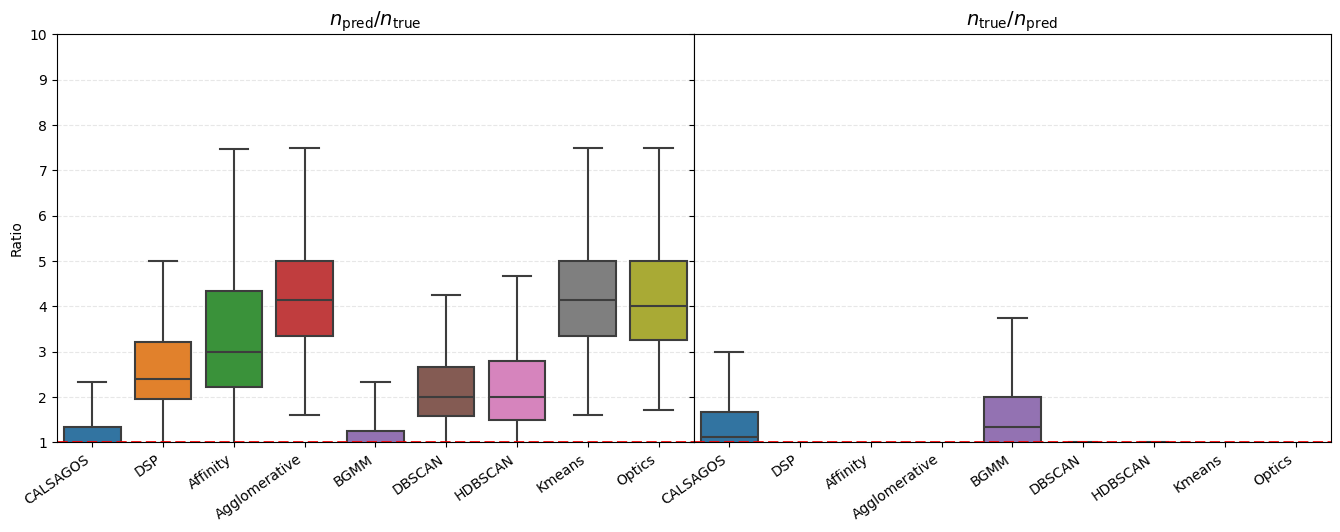

/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:487: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:509: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:528: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=35, ha="right")
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:528: UserWarning: set_ticklabels() should only be used with a f

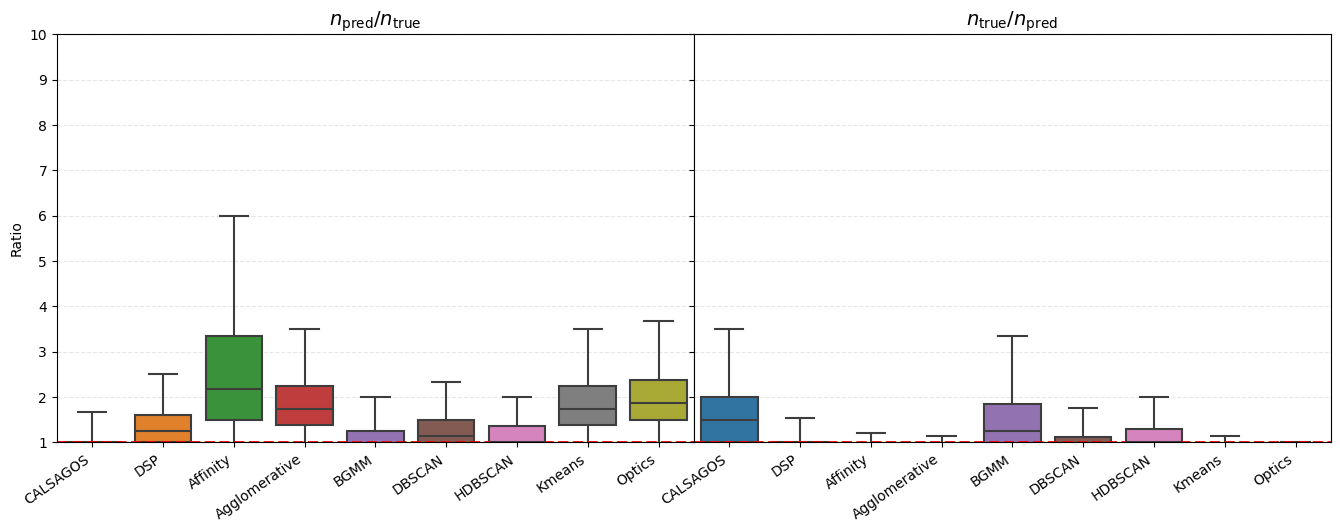

/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:487: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:509: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:528: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels, rotation=35, ha="right")
/home/gasep/Projects/GitHub/ClusteringComparison/ClusteringComparison/plot_maker.py:528: UserWarning: set_ticklabels() should only be used with a f

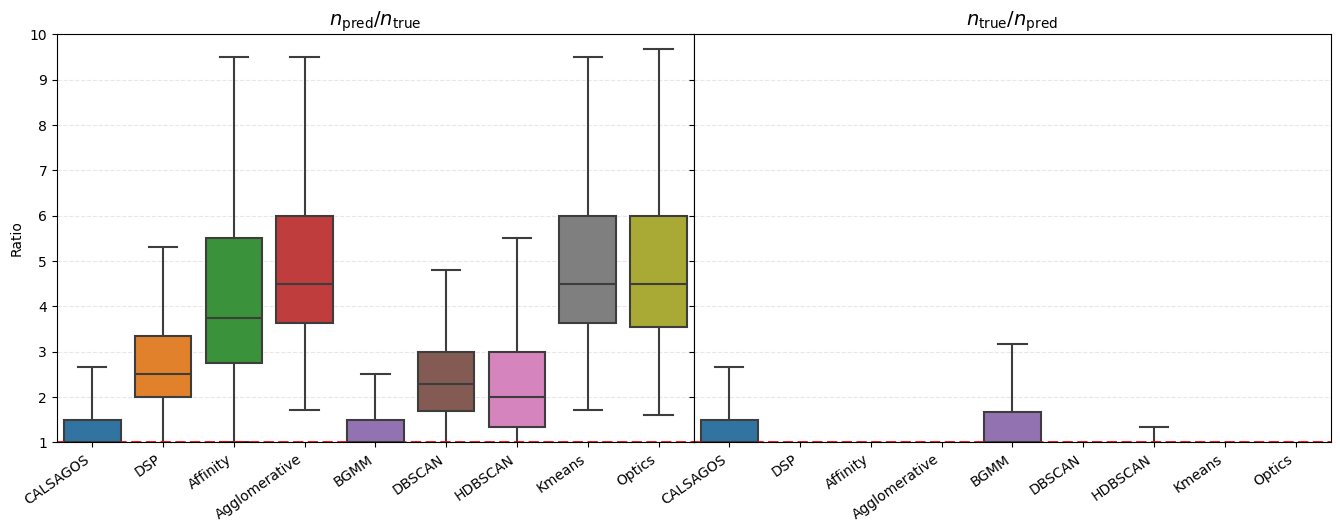

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plot_maker as pm

# --- LOAD ---
df = pd.read_csv("fragmentation_data_summary.csv")
df = df[df["Frag_Ratio"] > 0].copy()
df["Frag_Inverted"] = 1.0 / df["Frag_Ratio"]

save_dir = "Images/Fragmentation_DualView_Clipped"
os.makedirs(save_dir, exist_ok=True)

methods_order = sorted(df["Method"].unique())

display_labels = [
    m.replace("ML_", "") if m.startswith("ML_") else m
    for m in methods_order
]

palette = dict(zip(
    methods_order,
    sns.color_palette("tab10", n_colors=len(methods_order))
))

for key in ["Raw", "Clean", "SPLUS"]:
    df_key = df[df["Key"] == key]
    if df_key.empty:
        continue

    pm.frag_boxplot(df_key, methods_order=methods_order, display_labels=display_labels, palette=palette)

    out = f"{save_dir}/fragmentation_clipped_{key}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

In [16]:
import numpy as np
import pickle
import os
import cluster_utils as cu


partitioning_methods = [
    "ML_Kmeans",
    "ML_GMM",
    "ML_Aglomerative",
    "ML_Affinity"
]

keys = ["Raw", "Clean", "SPLUS"]
profiling_name = "Substructure_Proportions"

for key in keys:
    m_path = f"Metrics/M_F1/{key}/results.pkl"

    with open(m_path, "rb") as f:
        m_data = pickle.load(f)

    lookup = {
        str(df["firstHaloInFOFGroupId"].iloc[0]): df
        for df in cluster_samples[key]
    }

    method_radial_data = {}

    for method, halos_dict in m_data.items():
        is_part = any(pm in method for pm in partitioning_methods)

        cleaned_halos_dict = {}

        for h_id, f1_matrix_list in halos_dict.items():
            h_id_str = str(h_id)

            if h_id_str not in lookup:
                continue

            df = lookup[h_id_str]

            unique_ids = np.unique(df["haloId"].astype(str))
            noise_indices = [
                i for i, val in enumerate(unique_ids)
                if val in ["-1"]
            ]

            cleaned_list = []

            for f1_mat in f1_matrix_list:
                f1_arr = np.asarray(f1_mat)

                actual_clusters = f1_arr if is_part else f1_arr[:, 1:]

                if noise_indices:
                    actual_clusters = np.delete(
                        actual_clusters,
                        noise_indices,
                        axis=0
                    )

                cleaned_list.append(actual_clusters)

            cleaned_halos_dict[h_id] = cleaned_list

        method_radial_data[method] = cu.compute_best_f1_radial_fragmentation(
            halos_dict=cleaned_halos_dict,
            cluster_lookup=lookup
        )

    save_dir = f"Metrics/{profiling_name}/{key}"
    os.makedirs(save_dir, exist_ok=True)

    out_path = f"{save_dir}/fragmentation_radial.pkl"

    with open(out_path, "wb") as f:
        pickle.dump(method_radial_data, f)

    print(f"Saved: {out_path}")

Saved: Metrics/Substructure_Proportions/Raw/fragmentation_radial.pkl
Saved: Metrics/Substructure_Proportions/Clean/fragmentation_radial.pkl
Saved: Metrics/Substructure_Proportions/SPLUS/fragmentation_radial.pkl


Saved: Images/Radial_Fragmentation/fragmentation_vs_radius_Raw.png


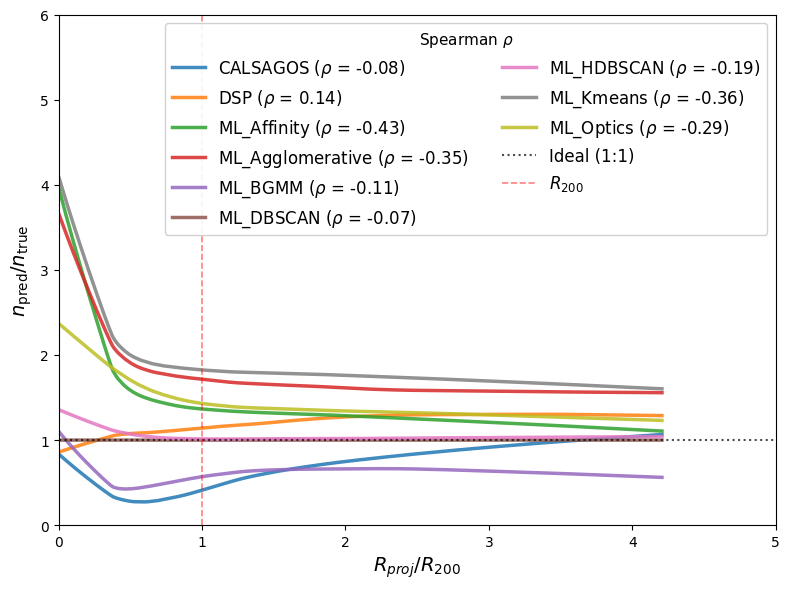

Saved: Images/Radial_Fragmentation/fragmentation_vs_radius_Clean.png


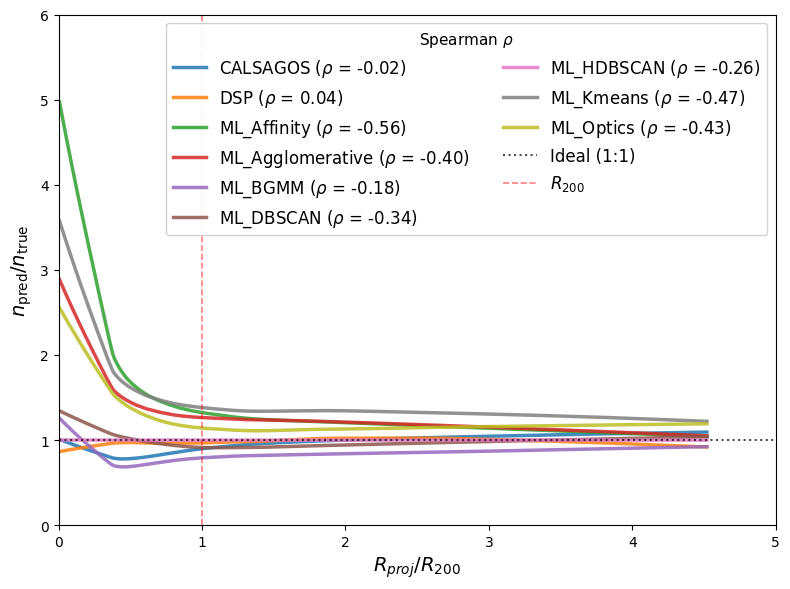

Saved: Images/Radial_Fragmentation/fragmentation_vs_radius_SPLUS.png


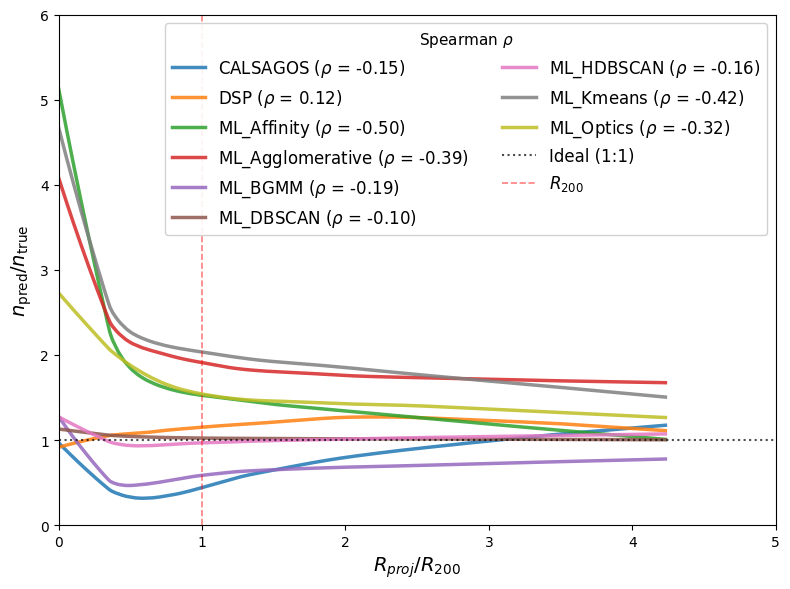

In [2]:
import os
import pickle
import numpy as np
import plot_maker as pm
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
profiling_name = "Substructure_Proportions"
save_dir = "Images/Radial_Fragmentation"
os.makedirs(save_dir, exist_ok=True)

for key in keys:
    file_path = f"Metrics/{profiling_name}/{key}/fragmentation_radial.pkl"

    if not os.path.exists(file_path):
        print(f"Missing file: {file_path}")
        continue

    with open(file_path, "rb") as f:
        data = pickle.load(f)

    pm.plot_fragmentation_radial(data)

    plt.tight_layout()
    filename = f"{save_dir}/fragmentation_vs_radius_{key}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Saved: {filename}")
    plt.show()